In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [ ]:
symbs = [
"BTC-USD", "ETH-USD", "XRP-USD", "LTC-USD", "ADA-USD", "SOL-USD", "DOT-USD","ENJ-USD", "ATOM-USD",  "FIL-USD", "VET-USD", "XTZ-USD", "AAVE-USD", "LINK-USD", "ALGO-USD", 
"AVAX-USD", "DOT-USD", "ZEC-USD", "CRV-USD", "SNX-USD", "XLM-USD", "AXS-USD",
# forex
"EURUSD=X", "JPY=X", "GBPUSD=X",  "EURJPY=X","GBPJPY=X","EURGBP=X","EURCAD=X", "EURCHF=X","CADUSD=X","CADJPY=X",
#"CHFJPY=X","GBPCHF=X", "AUDUSD=X", "NZDUSD=X", "AUDJPY=X","AUDCAD=X","AUDCHF=X","NZDJPY=X","NZDCAD=X","NZDCHF=X",
# acciones 
"AAPL", "MSFT", "GOOGL", "AMZN", "META","NVDA", "TSLA", "NFLX", "PLTR", "INTC", "ORCL", "IBM", "CSCO", "PYPL", "BABA", "KO", "V","ADBE", "JPM", "XOM", "CVX", "WMT", 
"DIS", "BA", "MCD", "NKE", "PFE", "HD", "VZ", "PEP", "T", "ABT", "CVS", "WFC", "LLY", "ACN", "MDT", "DHR", "NEE", "BMY", "AMGN", "QCOM", "TXN", "LOW", "INTU", "MMM", "GE", 
"CAT", "DE", #"F", "GM", "UPS", "FDX", "BA", "LMT", "RTX", "NOC", "GD", "HON", "UNP", "CSX", "NSC", "KSU", "DAL", "UAL", "LUV", "AAL", "JBLU",
# "ALK", "RCL", "CCL", "NCLH", "MAR", "HST", "WYN", "EXPE", "BKNG", "SPG", "VNO", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS",
# "UDR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR","VTR", "O", "EPR", "BXP", 
# "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", 
# "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR","VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", 
# "EQR", "AVB", "ESS", 
# indices 
"^GSPC",   # S&P 500
# "^DJI",    # Dow Jones. no esta en xm
"^IXIC",   # Nasdaq
# etfs
# "SI=F", # Silver
# "BZ=F", # BRENT
# "PL=F", # Platinum,
# "NG=F", # NATURAL GAS

]
symbs_crypto = [x for x in symbs if "-USD" in x]
symbs_forex = [x for x in symbs if "=X" in x]
symbs_stocks = [x for x in symbs if x not in symbs_crypto and x not in symbs_forex]
symbs = list(set(symbs))
print("Total:", len(symbs))
print("Crypto :", len(symbs_crypto), f"({(len(symbs_crypto)/len(symbs))*100:.0f}%)")
print("Forex:", len(symbs_forex), f"({(len(symbs_forex)/len(symbs))*100:.0f}%)")
print("Stocks:", len(symbs_stocks), f"({(len(symbs_stocks)/len(symbs))*100:.0f}%)")

In [ ]:
# from more_itertools import last
import yfinance as yf
SYMBOLS = symbs 

# EMAS
EMA_SHORT       = 20
EMA_MID         = 50
EMA_LONG        = 200
# RSI
RSI_PERIOD      = 14
# MACD
MACD_FAST       = 12
MACD_SLOW       = 26
MACD_SIGNAL     = 9
# Bollinger
BB_PERIOD       = 20
BB_STD          = 2.0
# Estocastico
STOCH_K         = 9
STOCH_D         = 3
STOCH_SLOWING   = 3  
# ATR
ATR_PERIOD      = 14
# ATR - Gestión de riesgo
ATR_MULT_SL     = 1.5           # Multiplicador ATR para Stop Loss
ATR_MULT_TP     = 3.0           # Multiplicador ATR para Take Profit (ratio 2:1)
# Parámetro principal: mínimo de reglas que deben cumplirse 
# Rango válido: 1–8. Recomendado: 5 (conservador-moderado), 4 (agresivo), 6 (muy conservador)
MIN_RULES_TO_SIGNAL = 5
# Umbrales RSI 
RSI_OVERSOLD    = 35 # 35
RSI_OVERBOUGHT  = 70 # 65
# Umbrales Estocástico
STOCH_OVERSOLD  = 25
STOCH_OVERBOUGHT = 75
# Umbrales de posición dentro del canal BB
BB_ENTRY_SELL_MIN  = 0.75   # Para VENDER: precio debe estar en el > 75% del canal
BB_ENTRY_BUY_MAX   = 0.25   # Para COMPRAR: precio debe estar en el < 25% del canal
BB_WAIT_SELL_MIN   = 0.45   # Por debajo de esto en venta  → esperar subida
BB_WAIT_BUY_MAX    = 0.55   # Por encima de esto en compra → esperar bajada
# VPVMA
BANDWITH=0.1 # 0.1 filtro para reducir señales falsas (default 0.1)
# Volatility
VOLATILITY_PERIOD = 20
# Hull MA
HMA_FAST = 21
HMA_SLOW = 55
# Breakout structure
BREAKOUT_N = 20

import pandas as pd
def calc_ema(series: pd.Series, period: int) -> pd.Series:
    return series.ewm(span=period, adjust=False).mean()


def calc_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calc_macd(close: pd.Series, fast: int, slow: int, signal: int):
    ema_fast   = calc_ema(close, fast)
    ema_slow   = calc_ema(close, slow)
    macd_line  = ema_fast - ema_slow
    signal_line = calc_ema(macd_line, signal)
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram


def calc_bollinger(close: pd.Series, period: int, std_mult: float):
    mid   = close.rolling(period).mean()
    std   = close.rolling(period).std()
    upper = mid + std_mult * std
    lower = mid - std_mult * std
    return upper, mid, lower


def calc_stochastic(high: pd.Series, low: pd.Series, close: pd.Series,
                    k_period: int, slowing: int, d_period: int):
    lowest_low   = low.rolling(k_period).min()
    highest_high = high.rolling(k_period).max()
    denom = (highest_high - lowest_low).replace(0, np.nan)
    
    raw_k = 100 * (close - lowest_low) / denom  # %K crudo
    k     = raw_k.rolling(slowing).mean()        # %K suavizado (Slowing)
    d     = k.rolling(d_period).mean()           # %D
    return k, d


def calc_atr(high: pd.Series, low: pd.Series, close: pd.Series,
             period: int) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(com=period - 1, min_periods=period).mean()


def calc_obv(close: pd.Series, volume: pd.Series) -> pd.Series:
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()


def calc_adx(high, low, close, period=14):
    tr = calc_atr(high, low, close, period) 

    up_move   = high.diff()
    down_move = -low.diff()

    plus_dm  = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0)

    plus_dm  = pd.Series(plus_dm,  index=close.index)
    minus_dm = pd.Series(minus_dm, index=close.index)

    atr      = tr
    plus_di  = 100 * plus_dm.ewm(com=period-1).mean()  / atr
    minus_di = 100 * minus_dm.ewm(com=period-1).mean() / atr

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.ewm(com=period-1).mean()

    return adx, plus_di, minus_di


def calc_bb_position(df):
    """
    Retorna la posición relativa del precio dentro del canal BB.
      0.0 → precio en la banda inferior
      0.5 → precio en la media (mitad del canal)
      1.0 → precio en la banda superior
    """
    return (df["Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + 1e-9)


def calculate_vpvma(df, window_fast=12, window_slow=26, window_sign=9):
    """
    VPVMA - Volume Price Volatility Moving Average
    Derivado del MACD por Pat Tong Chio (2022)
    
    Parámetros:
        df           : DataFrame con columnas Open, High, Low, Close, Volume
        window_fast  : período corto (default 12)
        window_slow  : período largo (default 26)
        window_sign  : período de señal (default 9)
        bandwidth    : filtro para reducir señales falsas (default 0.1)
    """
    df["TP"] = (df["High"] + df["Low"] + df["Close"]) / 3

    df["TP_x_Vol"] = df["TP"] * df["Volume"]

    df["SVWMA"] = (
        df["TP_x_Vol"].rolling(window=window_fast).sum() /
        df["Volume"].rolling(window=window_fast).sum()
    )

    df["LVWMA"] = (
        df["TP_x_Vol"].rolling(window=window_slow).sum() /
        df["Volume"].rolling(window=window_slow).sum()
    )

    df["DV"] = df[["Open", "High", "Low", "Close"]].std(axis=1)

    df["SVWMA_x_DV"] = df["SVWMA"] * df["DV"]
    df["LVWMA_x_DV"] = df["LVWMA"] * df["DV"]

    df["ESVMap"] = df["SVWMA_x_DV"].ewm(span=window_fast, adjust=False).mean()
    df["ELVMap"] = df["LVWMA_x_DV"].ewm(span=window_slow, adjust=False).mean()

    df["VPVMA"]  = df["ESVMap"] - df["ELVMap"]
    df["VPVMAS"] = df["VPVMA"].rolling(window=window_sign).mean()
    df.drop(columns = ["SVWMA", "TP", "TP_x_Vol", "SVWMA", "DV", "SVWMA_x_DV", "LVWMA_x_DV", "ESVMap", "ELVMap"], inplace = True)    


    return df


def evaluate_entry_quality(signal: str, bb_pos: float) -> dict:
    """
    Evalúa si el precio está en una zona ÓPTIMA para entrar o si es necesario esperar el REBOTE. 
    Se valida que no esteen la mitad del canal, sino en zonas XTREMs (superior para venta, inferior para compra).
    
    Zonas para VENDER (bb_pos):
    🟢 ZONA ÓPTIMA VENTA    (>= 0.75)      
    🟡 ZONA ACEPTABLE VENTA (0.55 – 0.75)  
    🔴 ESPERAR SUBIDA       (< 0.55)       

    Zonas para COMPRAR (bb_pos):
    🔴 ESPERAR BAJADA       (> 0.55)      
    🟡 ZONA ACEPTABLE COMPRA (0.25 – 0.45) 
    🟢 ZONA ÓPTIMA COMPRA   (<= 0.25) 
    """
    pct = bb_pos * 100 

    if "🔴" in signal:
        if bb_pos >= BB_ENTRY_SELL_MIN:
            return {
                "entry_ok":   True,
                "advice": "🔴",
                "entry_zone":     f"🔴",
                "bb_pct":     pct,
            }
        elif bb_pos >= BB_WAIT_SELL_MIN:
            return {
                "entry_ok":   False,
                "advice": "🟡", # Nivel aceptable, mejor esperar 
                "entry_zone":     (f"🟡 > {BB_ENTRY_SELL_MIN*100:.0f}%"),
                "bb_pct":     pct,
            }
        else:
            return {
                "entry_ok":   False,
                "advice": "⚪",
                "entry_zone":     (f"⚪ > {BB_ENTRY_SELL_MIN*100:.0f}%"), 
                "bb_pct":     pct,
            }

    elif "🟢" in signal:
        if bb_pos <= BB_ENTRY_BUY_MAX:
            return {
                "entry_ok":   True,
                "advice": "🟢",
                "entry_zone":     f"🟢",
                "bb_pct":     pct,
            }
        elif bb_pos <= BB_WAIT_BUY_MAX:
            return {
                "entry_ok":   False,
                "advice": "🟡",  
                "entry_zone":     (f"🟡 < {BB_ENTRY_BUY_MAX*100:.0f}%"),
                "bb_pct":     pct,
            }
        else:
            return {
                "entry_ok":   False,
                "advice": "⚪",
                "entry_zone":     (f"⚪ < {BB_ENTRY_BUY_MAX*100:.0f}%"),
                "bb_pct":     pct,
            }

    # Para ESPERAR no aplica
    return {"entry_ok": False, "entry_zone": "", "advice": "", "bb_pct": pct}

def calc_consistencia(close: pd.Series) -> pd.Series:
    prev26 = close.shift(26)
    prev52 = close.shift(52)

    return prev26, prev52

def build_indicators(df: pd.DataFrame) -> pd.DataFrame:
    c, h, l, v = df["Close"], df["High"], df["Low"], df["Volume"]

    df["EMA20"]  = calc_ema(c, EMA_SHORT)
    df["EMA50"]  = calc_ema(c, EMA_MID)
    df["EMA200"] = calc_ema(c, EMA_LONG)

    df["RSI"] = calc_rsi(c, RSI_PERIOD)

    df["MACD"], df["MACD_signal"], df["MACD_hist"] = calc_macd(
        c, MACD_FAST, MACD_SLOW, MACD_SIGNAL
    )

    df["BB_upper"], df["BB_mid"], df["BB_lower"] = calc_bollinger(c, BB_PERIOD, BB_STD)

    df["STOCH_K"], df["STOCH_D"] = calc_stochastic(h, l, c, STOCH_K, STOCH_SLOWING, STOCH_D)

    df["ATR"] = calc_atr(h, l, c, ATR_PERIOD)

    df["OBV"]     = calc_obv(c, v)
    df["OBV_EMA"] = calc_ema(df["OBV"], 20)

    df["ADX"], df["ADX+DI"], df["ADX-DI"] = calc_adx(h, l, c, period=14)

    df["prev26"], df["prev52"] = calc_consistencia(c)

    df = calculate_vpvma(df)

    df["VWAP"] = (df["Close"] * df["Volume"]).cumsum() / df["Volume"].cumsum()

    df["spread"] = (df["High"] - df["Low"]) / df["Close"]
    
    df["vol_ma"] = df["Volume"].rolling(20).mean()
    df["volume_increasing"] = df["Volume"] > df["vol_ma"]
    
    df["order_flow"] = np.where(df["Close"] > df["Open"], "buy", "sell")

    df["volatility"] = df["Close"].pct_change().rolling(VOLATILITY_PERIOD).std()

    df["trend_strength"] = abs(df["EMA20"] - df["EMA50"]) / df["Close"]

    df["regime"] = np.where(df["trend_strength"] > 0.01, "trend", "lateral") 

    df.dropna(inplace=True)
    return df


def fmt(n, decimals=4) -> str:
    if n is None:
        return "N/A"
    fmt_str = f"{{:,.{decimals}f}}"
    return fmt_str.format(n)


def compute_tp_sl(price: float, atr: float, direction: str) -> tuple:
    """
    Retorna (take_profit, stop_loss) basados en ATR.
    direction: 'BUY' o 'SELL'
    """
    if direction == "🟢":
        sl = price - ATR_MULT_SL * atr
        tp = price + ATR_MULT_TP * atr
    else:  # SELL
        sl = price + ATR_MULT_SL * atr
        tp = price - ATR_MULT_TP * atr
    return tp, sl

def analyze_symbol(symbol: str, INTERVAL:int, LOOKBACK_DAYS:int) -> dict:
    # symbol = "CVS" # usar antes del 15/04 ya que 3 estrategias se alinean para sell
    # LOOKBACK_DAYS = 40
    # INTERVAL = "1h"

    for _ in range(3):
        try:
            df = yf.download(
                symbol,
                period=f"{LOOKBACK_DAYS}d",
                interval=INTERVAL,
                progress=False,
                auto_adjust=True,
            )
        except Exception as e:
            print(f"ERROR: {symbol} - {e}")
            return pd.DataFrame()

        if len(df) > 0:
            break   

    if df.empty or len(df) < EMA_LONG + 10:
        print(f"ERROR: {symbol} - len(df) < {EMA_LONG + 10}")
        return pd.DataFrame()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["date"] = df.index
    df = build_indicators(df.copy())


    if len(df) < 2:
        print(f"ERROR: {symbol} - len(df) < 2")
        return pd.DataFrame()

    bb_pos   = calc_bb_position(df)


    # ------------------------------- SEÑALES -------------------------------#

    # ----------- 2. MACD + RSI
    """
    RSI bajo durante varias velas = presión vendedora estructural
    MACD cruzando = inicio del cambio
    Es un detector de “agotamiento + giro temprano”
    """
    df["rsi_below_35"] = (df["RSI"] < 35).astype(int)
    df["rsi_above_65"] = (df["RSI"] > 65).astype(int)

    df["count_men"] = df["rsi_below_35"].rolling(6, min_periods = 1).sum()
    df["count_may"] = df["rsi_above_65"].rolling(6, min_periods = 1).sum()

    df["macd_signal"] = np.where(
        df["MACD"] > df["MACD_signal"], 1,
        np.where(df["MACD"] < df["MACD_signal"], -1, 0)
    )

    # El umbral 4 originalmente era 6 (AJUSTE para que salgan señales)
    df["macdrsi_sign"] = np.where(
        (df["count_men"] >= 4) & (df["macd_signal"] == 1), "🟢",
        np.where(
            (df["count_may"] >= 4) & (df["macd_signal"] == -1), "🔴",
            ""
        )
    )

    # ---------- 2. VPVMA (volumen ponderado dinámico)
    """
    Qué mide: Precio ponderado por volumen vs su media
    Es parecido a VWAP, pero más “reactivo”
    Cruce = cambio en el equilibrio entre compradores/vendedores reales
    Detecta: “quién está ganando con dinero real”
    Riesgo: Sensible a spikes de volumen
    """

    signbuy_base = (
        (df["VPVMA"] > (1 + BANDWITH) * df["VPVMAS"]) &
        (df["VPVMA"].shift(1) <= df["VPVMAS"].shift(1))
    )

    signsell_base = (
        (df["VPVMA"] < (1 - BANDWITH * 2) * df["VPVMAS"]) &
        (df["VPVMA"].shift(1) >= df["VPVMAS"].shift(1))
    )

    window = 5 # shift(1)
    recent_buy = signbuy_base.rolling(window).max().fillna(0).astype(bool)
    recent_sell = signsell_base.rolling(window).max().fillna(0).astype(bool)

    df["vpvma_sign"] = np.where(
        recent_buy, "🟢",
        np.where(recent_sell, "🔴", "")
    )
    vpvma = df["vpvma_sign"].iloc[-1]


    # ----------- 3. Sinergia
    """
    “solo opero cuando TODO está alineado”
    Riesgo
    Puede filtrar demasiado (pocas señales)
    """
    long_cond = (
        (df["Close"] > df["EMA20"]) &
        (df["RSI"] > 55) &
        (df["MACD"] > df["MACD_signal"]) &
        (df["Close"] > df["VWAP"]) &
        (df["spread"] < 0.01) &
        (df["volume_increasing"]) &
        (df["order_flow"] == "buy")
    )

    short_cond = (
        (df["Close"] < df["EMA20"]) &
        (df["RSI"] < 45) &
        (df["MACD"] < df["MACD_signal"]) &
        (df["Close"] < df["VWAP"]) &
        (df["spread"] < 0.01) &
        (df["volume_increasing"]) &
        (df["order_flow"] == "sell")
    )

    df["sinergia_sign"] = ""
    df.loc[long_cond, "sinergia_sign"] = "🟢"
    df.loc[short_cond, "sinergia_sign"] = "🔴"
    sinergia = df["sinergia_sign"].iloc[-1]


    # ----------- 4. RSI mean reversion + Bollinger
    """
    Qué mide
    Desviación XTREM del precio respecto a la media
    Se predice que el precio hace una reversion a la media
    Interpretación: “el mercado se estiró demasiado, va a regresar”
    Riesgo: En tendencias fuertes, el precio sigue “rompiendo la banda”
    """

    df["reversionmean_sign"] = np.where((df['RSI'] < 30) & (df['Close'] <= df['Low']), "🟢", 
                    np.where((df['RSI'] > 70) & (df['Close'] >= df['High']), "🔴", ""))
    reversionmean = df["reversionmean_sign"].iloc[-1]
    

    # ----------- 5. Trend following: MA + MACD. 
    """
    Qué mide: Dirección + confirmación de momentum
    Interpretación: “me subo a la ola, no intento predecirla”
    Riesgo: Entradas tardías
    """
    
    df['trend'] = np.where(df['Close'] > df['EMA200'], 1, -1)

    df['long_signal'] = (
        (df['EMA50'] > df['EMA200']) &
        (df['MACD'] > df['MACD_signal']) &
        (df['trend'] == 1)
    )

    df['short_signal'] = (
        (df['EMA50'] < df['EMA200']) &
        (df['MACD'] < df['MACD_signal']) &
        (df['trend'] == -1)
    )

    # Evitar lookahead bias
    df['long_signal'] = df['long_signal'].shift(1)
    df['short_signal'] = df['short_signal'].shift(1)

    df["trendfollow_sign"] = ""
    df.loc[df['long_signal'] == True, "trendfollow_sign"] = "🟢"
    df.loc[df['short_signal'] == True, "trendfollow_sign"] = "🔴"

    trendfollow = df["trendfollow_sign"].iloc[-1]


    # ----------- 6. Squeeze + Keltner
    """
    Qué mide: Contracción de volatilidad
    Interpretación: “el mercado está comprimido → se viene explosión”
    Riesgo: No siempre predice dirección
    """

    length = 20
    mult_bb = 2.0
    mult_kc = 1.5

    # Bollinger Bands
    df['ma_20'] = df['Close'].rolling(window=length).mean()
    df['std_20'] = df['Close'].rolling(window=length).std()
    df['bb_upper'] = df['ma_20'] + (mult_bb * df['std_20'])
    df['bb_lower'] = df['ma_20'] - (mult_bb * df['std_20'])

    # Keltner Channels (Usando ATR para la banda)
    df['tr'] = np.maximum(df['High'] - df['Low'], 
                            np.maximum(abs(df['High'] - df['Close'].shift(1)), 
                                        abs(df['Low'] - df['Close'].shift(1))))
    df['atr_20'] = df['tr'].rolling(window=length).mean()
    df['kc_upper'] = df['ma_20'] + (mult_kc * df['atr_20'])
    df['kc_lower'] = df['ma_20'] - (mult_kc * df['atr_20'])

    # Lógica del Squeeze
    df['squeeze_on'] = (df['bb_upper'] < df['kc_upper']) & (df['bb_lower'] > df['kc_lower'])

    # Momentum (Filtro simple para dirección del squeeze)
    df['momentum'] = df['Close'] - df['Close'].shift(length)
    df["squeeze_sign"] = np.where((df['squeeze_on'] == True) & (df['momentum'] > 0), "🟢",  
                         np.where((df['squeeze_on'] == True) & (df['momentum'] < 0), "🔴", ""))


    # ---------- 7. Hull MA
    """
    Qué mide: Tendencia suavizada pero rápida
    Interpretación: Más rápida que EMA, menos ruido
    Detecta: cambios de tendencia más temprano
    """
    def calculate_hull_ma(series, n):
        def wma(s, period):
            weights = np.arange(1, period + 1)
            return s.rolling(period).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
        
        half_n = int(n / 2)
        sqrt_n = int(np.sqrt(n))
        
        val = 2 * wma(series, half_n) - wma(series, n)
        hma = wma(val, sqrt_n)
        return hma

    df['hma_fast'] = calculate_hull_ma(df['Close'], HMA_FAST)
    df['hma_slow'] = calculate_hull_ma(df['Close'], HMA_SLOW)

    df['hma_sign'] = np.where(df['hma_fast'] > df['hma_slow'], "🟢", 
                                np.where(df['hma_fast'] < df['hma_slow'], "🔴", ""))
    hma = df['hma_sign'].iloc[-1]


    #-------------------------------------- REGLAS ---------------------------------------#
    
    # ----------- 1. Golden Cross y Death Cross 
    """
    Qué mide: Cambio estructural de tendencia
    Interpretación: Es una señal “lenta pero fuerte”
    Riesgo: Muy retrasada
    """
    golden_base = (
        (df["EMA20"] > df["EMA50"]) &
        (df["EMA20"].shift(1) <= df["EMA50"].shift(1))
    )

    death_base = (
        (df["EMA20"] < df["EMA50"]) &
        (df["EMA20"].shift(1) >= df["EMA50"].shift(1))
    )

    window = 6# shift(1)
    recent_golden = golden_base.rolling(window).max().fillna(0).astype(bool)
    recent_death = death_base.rolling(window).max().fillna(0).astype(bool)

    df["golden_sign"] = np.where(recent_golden, "🟢", np.where(recent_death, "🔴", ""))


    # ----------- 2. Volumen — OBV 
    """
    Qué mide: Flujo acumulado de volumen
    Interpretación: “el dinero entra antes que el precio”
    # Volumen confirma presión compradora o vendedora
    """
    df["volume_sign"] =  np.where(df["OBV"] > df["OBV_EMA"],  "🟢", 
                         np.where(df["OBV"] < df["OBV_EMA"],  "🔴", ""))
    volume = df["volume_sign"].iloc[-1]
        

    # ----------- 3. 3-EMA alignment
    """
    Qué mide: Jerarquía de tendencias
    Interpretación: mercado ordenado vs caótico
    """
    df['3ema_sign'] = np.where((df['EMA20'] > df['EMA50']) & (df['EMA50'] > df['EMA200']), "🟢",  np.where((df['EMA20'] < df['EMA50']) & (df['EMA50'] < df["EMA200"]), "🔴", ""))
    ema3 = df['3ema_sign'].iloc[-1]


    # ----------- 4. Sobrecompra y sobreventa RSI
    df["rsi_sign"] = np.where((df["RSI"] < 30), "OVERSELL", 
                                     np.where((df["RSI"] > 70), "OVERBUY", ""))


    # ----------- 5. ADX + DI - Direccion y fuerza tendencia
    """
    Qué mide: Fuerza + dirección
    Interpretación: diferencia entre tendencia real vs ruido
    """
    def classify(row):
        adx_val   = row["ADX"]
        p_di      = row["ADX+DI"]
        m_di      = row["ADX-DI"]
        precio    = row["Close"]
        ema200    = row["EMA200"]

        if pd.isna(adx_val) or pd.isna(p_di) or pd.isna(m_di):
            return "- 0"

        #  Mercado lateral: ADX muy bajo, sin dirección clara
        if adx_val < 15:
            return ""

        # Determinar dirección
        alcista = (p_di > m_di) and (precio > ema200)
        bajista = (m_di > p_di) and (precio < ema200)

        # Caso borde: DI's apuntan contra EMA200 (conflicto de señales)
        if not alcista and not bajista:
            if p_di > m_di:
                return "▲ 1"   # alcista pero bajo EMA200
            elif m_di > p_di:
                return "▼ 1"   # bajista pero sobre EMA200
            else:
                return ""

        # Clasificar por fuerza del ADX
        if alcista:
            if adx_val >= 70:
                return "▲ 5 SUPER XTREM"
            elif adx_val >= 60:
                return "▲ 4 XTREM"
            elif adx_val >= 40:
                return "▲ 3"
            elif adx_val >= 25:
                return "▲ 2"
            else:             
                return "▲ 1"
        if bajista:
            if adx_val >= 70:
                return "▼ 5 SUPER XTREM"
            elif adx_val >= 60:
                return "▼ 4 XTREM"
            elif adx_val >= 40:
                return "▼ 3"
            elif adx_val >= 25:
                return "▼ 2"
            else:
                return "▼ 1"

        return ""

    df["trend"] = df.apply(classify, axis=1)


    # ----------- 6. Breakout de estructura
    """
    BUY: rompe el máximo de N velas
    SELL: rompe el mínimo de N velas    
    Qué mide: no mide “indicadores”… mide estructura pura de precio.
    Máximos y mínimos recientes = zonas donde el mercado ya tomó decisiones
    Cuando se rompen → cambia el equilibrio
    Interpretación profunda: Un breakout es literalmente:
    “los compradores (o vendedores) absorbieron toda la liquidez disponible en ese nivel”
    No es solo un cruce… es consumo de órdenes pendientes

    Breakout sin volumen → sospechoso
    Breakout + volumen → institucional
    """

    max_bars_since_break = 5  # límite de velas válidas
    strength_factor = 0.5

    df["hh"] = df["High"].rolling(BREAKOUT_N).max()
    df["ll"] = df["Low"].rolling(BREAKOUT_N).min()

    df["range"] = df["High"] - df["Low"]

    df["break_up"] = (
        (df["Close"] > df["hh"].shift(1)) &
        (df["Close"].shift(1) <= df["hh"].shift(2))
    )

    df["break_down"] = (
        (df["Close"] < df["ll"].shift(1)) &
        (df["Close"].shift(1) >= df["ll"].shift(2))
    )

    df["strong_break_up"] = (
        df["break_up"] &
        (df["Close"] > df["hh"].shift(1) + strength_factor * df["range"])
    )

    df["strong_break_down"] = (
        df["break_down"] &
        (df["Close"] < df["ll"].shift(1) - strength_factor * df["range"])
    )

    df["bars_since_break_up"] = np.where(df["strong_break_up"], 0, np.nan)
    df["bars_since_break_down"] = np.where(df["strong_break_down"], 0, np.nan)

    df["bars_since_break_up"] = df["bars_since_break_up"].ffill()
    df["bars_since_break_down"] = df["bars_since_break_down"].ffill()

    df["bars_since_break_up"] = df["bars_since_break_up"].groupby(
        df["bars_since_break_up"].notna().cumsum()
    ).cumcount()

    df["bars_since_break_down"] = df["bars_since_break_down"].groupby(
        df["bars_since_break_down"].notna().cumsum()
    ).cumcount()

    df["msb_sign"] = np.where(
        (df["bars_since_break_up"] <= max_bars_since_break), "🟢",
        np.where((df["bars_since_break_down"] <= max_bars_since_break), "🔴", "")
    )

    msb = df["msb_sign"].iloc[-1]


    # ----------- 7. ATR - Explosion de Volatilidad
    """
    ATR = rango promedio de movimiento
    Comparas ATR actual vs histórico
    Interpretación: el mercado pasa de “respirar” a “correr”. Es cambio de régimen de volatilidad
    Baja volatilidad → mean reversion funciona mejor
    Alta volatilidad → trend following domina
    Este indicador te dice qué estrategia usar, no solo cuándo entrar
    """
    MIN_ATR = 1.06 # Mas alta: menos señales
    df["atr_mean"] = df["ATR"].rolling(20).mean()
    df["volume_expan"] = np.where(df["ATR"] > MIN_ATR * df["atr_mean"], "ALTA", "")
    df["rev_mean_atr_sign"] = np.where(df["reversionmean_sign"].isin(["🟢", "🔴"]) & (df["volume_expan"]== ""),df["reversionmean_sign"],  "")
    # Se añade rolling (antes 99.7% = "")
    sign_numeric = df["rev_mean_atr_sign"].map({"🟢":1, "":0, "🔴":-1}).fillna(0)
    buy_sign = (sign_numeric == 1).rolling(3, min_periods = 1).sum()
    sell_sign = (sign_numeric == -1).rolling(4, min_periods = 1).sum()
    df["rev_mean_atr_sign2"] = np.where(buy_sign > sell_sign, "🟢", 
                            np.where(sell_sign > buy_sign, "🔴", ""))
        
    reversionmean_atr = df["rev_mean_atr_sign"].iloc[-1]
    

    # ----------- 8. Pullback + EMA
    """
    Qué mide: Retroceso dentro de tendencia
    Interpretación: no persigo el precio, espero descuento
    Es lo que hacen traders institucionales: Compran en retrocesos. No en rompimientos emocionales

    Mejora el ratio riesgo/beneficio brutalmente. Reduce drawdowns
    """
    df["pullback_sign"] = np.where(
        (df["Close"] > df["EMA50"]) &
        (df["Low"] <= df["EMA20"]) &
        (df["Close"] > df["EMA20"]),
        "🟢",
        np.where(
            (df["Close"] < df["EMA50"]) &
            (df["High"] >= df["EMA20"]) &
            (df["Close"] < df["EMA20"]),
            "🔴", ""))
    pullback = df["pullback_sign"].iloc[-1]


    # ----------- 9. Divergencia RSI - agotamiento 
    """
    Qué mide: Desacople entre precio y momentum
    Interpretación: el precio sigue subiendo… pero con menos fuerza interna. Es como un coche subiendo una montaña 
    con el motor fallando.

    Muy potente en techos/suelos
    Mejor en temporalidades altas

    Precio hace lower low, RSI no → BUY
    Precio hace higher high, RSI no → SELL
    """
    df["price_diff"] = df["Close"].diff()
    df["rsi_diff"] = df["RSI"].diff()

    df["divrsi_sign"] =np.where(
        (df["price_diff"] < 0) & (df["rsi_diff"] > 0),
        "🟢",
        np.where(
            (df["price_diff"] > 0) & (df["rsi_diff"] < 0),
            "🔴", ""
        )
    )


    # ----------- 10. VWAP Deviation
    """
    Muy lejos del VWAP → reversión probable
    Qué mide: Distancia respecto al precio promedio ponderado
    Interpretación: qué tan “caro” o “barato” está el precio en el día

    Institucionales usan VWAP como referencia. Grandes desviaciones → reversión probable
    """
    df["vwap_dev"] = (df["Close"] - df["VWAP"]) / df["VWAP"]

    df["vwap_dev_sign"] = np.where(df["vwap_dev"] < -0.02, "🟢",
                np.where(df["vwap_dev"] > 0.02, "🔴", ""))
    vwap_dev = df["vwap_dev_sign"].iloc[-1]


    # 11. ----------- Support / Resistance dinámico 
    """
    Qué mide: Zonas donde el precio ha reaccionado antes
    Interpretación: memoria del mercado. Los traders recuerdan esos niveles… y actúan ahí

    Más fuerte si coincide con volumen
    Más fuerte si coincide con estructura
    """
    n = 50
    lookback_break = 5  # máximo de velas desde el rompimiento

    df["resistance"] = df["High"].rolling(n).max()
    df["support"] = df["Low"].rolling(n).min()

    df["break_up"] = (df["Close"] > df["resistance"].shift(1))
    df["break_down"] = (df["Close"] < df["support"].shift(1))

    df["bars_since_break_up"] = (~df["break_up"]).cumsum() - (~df["break_up"]).cumsum().where(df["break_up"]).ffill()
    df["bars_since_break_down"] = (~df["break_down"]).cumsum() - (~df["break_down"]).cumsum().where(df["break_down"]).ffill()

    df["supor_resis_sign"] = np.where(
        df["bars_since_break_up"] <= lookback_break, "🔴",
        np.where(df["bars_since_break_down"] <= lookback_break, "🟢", "")
    )
    sr = df["supor_resis_sign"].iloc[-1]


    # ----------- 13. Heikin Ashi Trend
    """
    Suaviza velas → mejor lectura de tendencia
    Qué mide: Tendencia suavizada
    Interpretación: elimina ruido emocional del mercado

    Ideal para mantener posiciones
    No para entradas precisas
    """
    df["ha_close"] = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4
    df["ha_open"]  = (df["Open"].shift(1) + df["Close"].shift(1)) / 2

    df["ha_sign"] = np.where(df["ha_close"] > df["ha_open"], "🟢",
                np.where(df["ha_close"] < df["ha_open"], "🔴", ""))
    ha_signal = df["ha_sign"].iloc[-1]


    # ----------- 14. Momentum puro (Rate of Change)
    """
    Mide velocidad del precio (aceleración)
    Qué mide: velocidad del precio
    Interpretación: qué tan rápido se mueve el mercado

    Momentum precede a tendencia
    """
    n = 10
    df["roc"] = df["Close"].pct_change(n)

    df["momentum_sign"] = np.where(df["roc"] > 0.02, "🟢",
                np.where(df["roc"] < -0.02, "🔴", ""))
    momentum = df["momentum_sign"].iloc[-1]


    # # ----------- 15. Volumen anómalo (Volume Spike)
    """
    Detecta actividad institucional o eventos
    Qué mide: volumen anormal
    Interpretación: actividad institucional o evento importante

    Confirmación clave de movimientos
    """
    df["vol_mean"] = df["Volume"].rolling(20).mean()

    df["volspike_sign"] = np.where(df["Volume"] > 2 * df["vol_mean"], "✅", "")
    volume_spike = df["volspike_sign"].iloc[-1]


    # ----------- 16. Range Compression (antes de breakout)
    """
    Detecta consolidación XTREM
    Qué mide: reducción XTREM del rango
    Interpretación: mercado “apretado” antes de moverse
F
    Precede breakouts
    """
    df["range"] = df["High"] - df["Low"]
    df["range_mean"] = df["range"].rolling(20).mean()

    df["compress_sign"] = np.where(df["range"] < 0.5 * df["range_mean"], "✅", "")
    compression = df["compress_sign"].iloc[-1]


    # ----------- 17. EMA Distance (sobre-extensión)
    """
    Detecta cuando el precio está demasiado lejos de la media
    Qué mide: sobre-extensión del precio
    Interpretación: el precio se alejó demasiado de su equilibrio

    Evita entrar tarde
    Ideal para contrarian trades
    """
    df["ema_dist"] = (df["Close"] - df["EMA50"]) / df["EMA50"]

    df["emadist_sign"] = np.where(df["ema_dist"] > 0.03, "🔴",
                    np.where(df["ema_dist"] < -0.03, "🟢", ""))
    ema_distance = df["emadist_sign"].iloc[-1]


    # ----------- 18. Supertrend (ATR-based dynamic S/R)
    """
    Genera soporte/resistencia dinámico basado en ATR. Excelente complemento al HMA porque confirma dónde está el soporte, no solo la dirección.
    """
    def calc_supertrend(df, period=10, multiplier=3.0):
        hl2 = (df["High"] + df["Low"]) / 2
        atr = df["ATR"]

        upper = hl2 + (multiplier * atr)
        lower = hl2 - (multiplier * atr)

        supertrend = pd.Series(index=df.index, dtype=float)
        direction = pd.Series(index=df.index, dtype=int)

        supertrend.iloc[0] = upper.iloc[0]
        direction.iloc[0] = 1

        for i in range(1, len(df)):
            prev_st = supertrend.iloc[i-1]
            prev_dir = direction.iloc[i-1]

            up = upper.iloc[i]
            dn = lower.iloc[i]

            if prev_dir == 1:
                up = min(up, prev_st)
            else:
                dn = max(dn, prev_st)

            if df["Close"].iloc[i] > up:
                direction.iloc[i] = -1
            elif df["Close"].iloc[i] < dn:
                direction.iloc[i] = 1
            else:
                direction.iloc[i] = prev_dir

            supertrend.iloc[i] = dn if direction.iloc[i] == -1 else up

        df["supertrend"] = supertrend
        df["st_direction"] = direction
        return df
    
    df = calc_supertrend(df)
    df["st_direction"] = df["st_direction"].astype(int).astype(str).replace({"-1":"🔴", "1":"🟢", "0":""})
    supertrend = df["st_direction"].iloc[-1]


    # ----------- 19. Stochastic K/D crossover en zonas XTREMs
    """
    Tu sistema tiene Stochastic calculado pero comentado. Esta señal aprovecha el cruce K/D en zonas XTREMs.
    """
    df["stochcross_sign"] = np.where((df["STOCH_K"] < 25) & (df["STOCH_D"] < 25) & (df["STOCH_K"].shift(1) < df["STOCH_D"].shift(1)) & (df["STOCH_K"] > df["STOCH_D"]), "🟢",
                            np.where((df["STOCH_K"] > 75) & (df["STOCH_D"] > 75) & (df["STOCH_K"].shift(1) > df["STOCH_D"].shift(1)) & (df["STOCH_K"] < df["STOCH_D"]), "🔴", ""))

    stochastic = df["stochcross_sign"].iloc[-1]


    # ----------- 20. Chaikin Money Flow (CMF)
    # Mide la presión compradora/vendedora ponderada por volumen durante N períodos. Más sensible que el OBV a cambios intradía.
    CMF_PERIOD = 20
    CMF_UMBRAL = 0.05

    df["CLV"] = ((df["Close"] - df["Low"]) - (df["High"] - df["Close"])) / (df["High"] - df["Low"] + 1e-9)
    df["CMF"] = (df["CLV"] * df["Volume"]).rolling(CMF_PERIOD).sum() / df["Volume"].rolling(CMF_PERIOD).sum()

    df["CMF_sign"] = np.where((df["CMF"] > CMF_UMBRAL) & (df["CMF"] > df["CMF"].shift(1)), "🟢", 
                              np.where((df["CMF"] < -CMF_UMBRAL) & (df["CMF"] < df["CMF"].shift(1)), "🔴", ""))
    cmf = df["CMF_sign"].iloc[-1]


    # ----------- 21. Parabolic SAR
    # Excelente para gestión de stops dinámicos y detección de reversiones. Complementa al Supertrend — juntos forman una doble confirmación ATR-based.
    def calc_psar(df, iaf=0.02, maxaf=0.2):

        df = df.copy()

        length = len(df)
        high = df["High"].values
        low = df["Low"].values

        psar = np.zeros(length)

        bull = True
        af = iaf
        hp = high[0]
        lp = low[0]

        # Inicialización
        psar[0] = low[0]
        psar[1] = low[0]

        for i in range(2, length):

            if bull:
                psar[i] = psar[i-1] + af * (hp - psar[i-1])
                psar[i] = min(psar[i], low[i-1], low[i-2])

                if low[i] < psar[i]:
                    bull = False
                    psar[i] = hp
                    lp = low[i]
                    af = iaf
                else:
                    if high[i] > hp:
                        hp = high[i]
                        af = min(af + iaf, maxaf)

            else:
                psar[i] = psar[i-1] + af * (lp - psar[i-1])
                psar[i] = max(psar[i], high[i-1], high[i-2])

                if high[i] > psar[i]:
                    bull = True
                    psar[i] = lp
                    hp = high[i]
                    af = iaf
                else:
                    if low[i] < lp:
                        lp = low[i]
                        af = min(af + iaf, maxaf)

        df["PSAR"] = psar

        # Señal
        df["psar_sign"] = np.where(
            df["Close"] > df["PSAR"], "🟢",
            np.where(df["Close"] < df["PSAR"], "🔴", "")
        )

        return df
    
    df = calc_psar(df)
    psar = df["PSAR"].iloc[-1]


    # # ----------- 22. Elder Ray Index
    # Mide la diferencia entre el precio y una EMA. El Bull Power es High - EMA13, Bear Power es Low - EMA13. 
    # Detecta si los compradores/vendedores están ganando fuerza dentro de la tendencia.

    EMA_ELDER = 13
    df["EMA13"]      = df["Close"].ewm(span=EMA_ELDER, adjust=False).mean()
    df["bull_power"] = df["High"] - df["EMA13"]
    df["bear_power"] = df["Low"]  - df["EMA13"]

    # Señal: tendencia alcista con bear_power cruzando hacia positivo (compresión terminando)
    df["edr_sign"] = np.where((df["bull_power"].shift(1) > 0) & (df["bear_power"].shift(1) < 0) & (df["bear_power"].shift(2) < df["bear_power"].shift(1)), "🟢",
                     np.where((df["bull_power"].shift(1) < 0) & (df["bear_power"].shift(1) > 0) & (df["bull_power"].shift(2) < df["bull_power"].shift(1)), "🟢", ""))
    elder_ray = df["edr_sign"].iloc[-1]


    # ----------- 23. Williams %R
    # Similar al Stochastic pero más reactivo. Útil para detectar zonas de agotamiento rápido, especialmente en intradía.
    WILLR_PERIOD = 14
    highest_high = df["High"].rolling(WILLR_PERIOD).max()
    lowest_low   = df["Low"].rolling(WILLR_PERIOD).min()
    df["WillR"]  = -100 * (highest_high - df["Close"]) / (highest_high - lowest_low + 1e-9)

    # Saliendo de zonas XTREMs (más preciso que entrar en ellas)
    df["willr_sign"] = np.where((df["WillR"].shift(-2) < -80) & (df["WillR"].shift(-1) > -80), "🟢",   # saliendo de sobreventa
                        np.where((df["WillR"].shift(-2) > -20) & (df["WillR"].shift(-1) < -20), "🔴", "")) # saliendo de sobrecompra

    # ----------- 25. Donchian Channel Breakout
    """
    Captura rupturas de rango después de consolidación. Complementa perfectamente al Squeeze porque el Squeeze dice cuándo viene el movimiento y Donchian dice si ya rompió.
    Detecta ruptura de máximos/mínimos recientes (tendencia fuerte)
    """
    n = 20
    df["donchian_high"] = df["High"].rolling(n).max()
    df["donchian_low"]  = df["Low"].rolling(n).min()

    df["donchian_sign"] = np.where(df["Close"] > df["donchian_high"].shift(1), "🟢",
                                   np.where(df["Close"] < df["donchian_low"].shift(1), "🔴", ""))
    donchian = df["donchian_sign"].iloc[-1]


    # ----------- 26. Liquidity Sweep (caza de stops)
    #    Muy usado por smart money.

    # Lógica
    # Rompe máximo previo pero cierra por debajo → trampa → SELL
    # Rompe mínimo previo pero cierra por encima → BUY

    df["prev_high"] = df["High"].shift(1)
    df["prev_low"] = df["Low"].shift(1)

    df["liquid_sign"] = np.where(
        (df["High"] > df["prev_high"]) & (df["Close"] < df["prev_high"]),
        "🔴",
        np.where(
            (df["Low"] < df["prev_low"]) & (df["Close"] > df["prev_low"]),
            "🟢", ""
        )
    )
    liquidity = df["liquid_sign"].iloc[-1]


    # ----------- 27. Stoch RSI
    df["rsi_min"] = df["RSI"].rolling(14).min()
    df["rsi_max"] = df["RSI"].rolling(14).max()

    df["stoch_rsi"] = (df["RSI"] - df["rsi_min"]) / (df["rsi_max"] - df["rsi_min"])

    df["stoch_rsi_sign"] = np.where(df["stoch_rsi"] < 0.2, "🟢",
                                    np.where(df["stoch_rsi"] > 0.8, "🔴", ""))
    stoch_signal = df["stoch_rsi_sign"].iloc[-1]
    del df["stoch_rsi"]
    

    # ----------- 28. Divergencias RSI (esto te falta fuerte)
        # Detecta agotamiento real del movimiento.

    # Lógica
    # Precio hace lower low, RSI no → BUY
    # Precio hace higher high, RSI no → SELL

    df["price_diff"] = df["Close"].diff()
    df["rsi_diff"] = df["RSI"].diff()

    df["divrsi_sign"] = np.where(
        (df["price_diff"] < 0) & (df["rsi_diff"] > 0),
        "🟢",
        np.where(
            (df["price_diff"] > 0) & (df["rsi_diff"] < 0),
            "🔴", ""
        )
    )
    divergence_rsi2 = df["divrsi_sign"].iloc[-1]


    # ----------- 28. Divergencia MACD
    def compute_macd(df, fast=12, slow=26, signal=9):
        ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
        ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

        macd = ema_fast - ema_slow
        macd_signal = macd.ewm(span=signal, adjust=False).mean()
        hist = macd - macd_signal

        df = df.copy()
        df["MACD"] = macd
        df["MACD_signal"] = macd_signal
        df["MACD_hist"] = hist

        return df


    def find_pivots(series, left=3, right=3):
        pivots_high = []
        pivots_low = []

        for i in range(left, len(series) - right):
            window = series[i-left:i+right+1]

            if series.iloc[i] == window.max():
                pivots_high.append(i)

            if series.iloc[i] == window.min():
                pivots_low.append(i)

        return pivots_high, pivots_low


    def detect_macd_divergence(df, left=3, right=3):

        df = compute_macd(df)

        price = df["Close"]
        macd = df["MACD"]

        highs, lows = find_pivots(price, left, right)

        signals = pd.DataFrame(index=df.index)
        signals["bullish_div"] = False
        signals["bearish_div"] = False

        for i in range(1, len(lows)):
            prev = lows[i-1]
            curr = lows[i]

            # precio hace mínimo más bajo
            price_ll = price.iloc[curr] < price.iloc[prev]

            # MACD hace mínimo más alto
            macd_hl = macd.iloc[curr] > macd.iloc[prev]

            if price_ll and macd_hl:
                signals.loc[df.index[curr], "bullish_div"] = True

        for i in range(1, len(highs)):
            prev = highs[i-1]
            curr = highs[i]

            # precio hace máximo más alto
            price_hh = price.iloc[curr] > price.iloc[prev]

            # MACD hace máximo más bajo
            macd_lh = macd.iloc[curr] < macd.iloc[prev]

            if price_hh and macd_lh:
                signals.loc[df.index[curr], "bearish_div"] = True

        return signals["bearish_div"], signals["bullish_div"]

    df["bearish_div"], df["bullish_div"] = detect_macd_divergence(df)

    df["tempsignal"] = np.where(df["bullish_div"], "🟢", np.where(df["bearish_div"], "🔴", ""))

    window = 5
    recent_signal = (
        df["tempsignal"]
        .replace("", np.nan)
        .shift(1)
        .ffill(limit=window)
    )

    df["div_macd"] = recent_signal.fillna("")

    df["div_macd"] = df["div_macd"].where(df["div_macd"] != df["div_macd"].shift(1), "")
    del df["tempsignal"], df["bullish_div"], df["bearish_div"]



    #---------------------------------- OTRAS REGLAS --------------------------------#
    # A. EXPLOSIÓN
    buy_explosion = (
        (df["donchian_sign"] == "🟢") &
        (df["volspike_sign"] == "✅") &
        (df["volume_expan"] == "ALTA") &
        (df["Close"] > df["VWAP"])
    )

    sell_explosion = (
        (df["donchian_sign"] == "🔴") &
        (df["volspike_sign"] == "✅") &
        (df["volume_expan"] == "ALTA") &
        (df["Close"] < df["VWAP"])
    )

    # Se añade rolling
    buy_explosion = buy_explosion.rolling(3, min_periods=1).sum()
    sell_explosion = sell_explosion.rolling(3, min_periods=1).sum()

    df["strat_explosion"] = np.where(buy_explosion > sell_explosion, "🟢",
                            np.where(sell_explosion > buy_explosion, "🔴", ""))


    # B. REVERSIÓN INSTITUCIONAL
    buy_reversal = (
        (df["liquid_sign"] == "🟢") &
        (df["vwap_dev_sign"] == "🟢") &
        (df["divrsi_sign"] == "🟢")
    )

    sell_reversal = (
        (df["liquid_sign"] == "🔴") &
        (df["vwap_dev_sign"] == "🔴") &
        (df["divrsi_sign"] == "🔴")
    )

    # Nunca se cumple la divergencia divrsi_sign entonces no hay señal
    buy_reversal = buy_reversal.rolling(3, min_periods=1).sum()
    sell_reversal = sell_reversal.rolling(3, min_periods=1).sum()

    df["strat_revinstitu"] = np.where(buy_reversal > sell_reversal, "🟢",
                            np.where(sell_reversal > buy_reversal, "🔴", ""))


    # C. PULLBACK PERFECTO
    buy_pullback = (
        df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"]) &
        (df["pullback_sign"] == "🟢") &
        (df["stoch_rsi_sign"] == "🟢")
    )

    sell_pullback = (
        df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"]) &
        (df["pullback_sign"] == "🔴") &
        (df["stoch_rsi_sign"] == "🔴")
    )
    # Se añade rolling
    buy_pullback = buy_pullback.rolling(3, min_periods=1).sum()
    sell_pullback = sell_pullback.rolling(3, min_periods=1).sum()

    df["strat_pullback"] = np.where(buy_pullback > sell_pullback, "🟢",
                            np.where(sell_pullback > buy_pullback, "🔴", ""))


    # D. SQUEEZE
    sign_numeric = df["squeeze_sign"].map({"🟢": 1, "🔴": -1}).fillna(0)
    buy_count  = (sign_numeric == 1).rolling(3, min_periods=1).sum()
    sell_count = (sign_numeric == -1).rolling(3, min_periods=1).sum()
    df["squeeze_sign"] = np.where(buy_count > sell_count, "🟢", np.where(sell_count > buy_count, "🔴", ""))

    buy_squeeze_combo = (
        (df["compress_sign"] == "✅") &
        (df["squeeze_sign"] == "🟢") &
        (df["momentum_sign"] == "🟢")
    )

    sell_squeeze_combo = (
        (df["compress_sign"] == "✅") &
        (df["squeeze_sign"] == "🔴") &
        (df["momentum_sign"] == "🔴")
    )

    # Se añade rolling
    buy_squeeze_combo = buy_squeeze_combo.rolling(3, min_periods=1).sum()
    sell_squeeze_combo = sell_squeeze_combo.rolling(3, min_periods=1).sum()

    # No se cumple nunca ninguna de las condiciones, si se cumplen si se aumenta rolling de squeeze
    df["strat_squeeze"] = np.where(buy_squeeze_combo > sell_squeeze_combo, "🟢",
                            np.where(sell_squeeze_combo > buy_squeeze_combo, "🔴", ""))
    

    # E. ESTRUCTURA
    buy_structure = (
        (df["3ema_sign"] == "🟢") &
        (df["hma_sign"] == "🟢") &
        (df["volume_sign"] == "🟢") &
        (df["Close"] > df["EMA200"])
    )

    sell_structure = (
        (df["3ema_sign"] == "🔴") &
        (df["hma_sign"] == "🔴") &
        (df["volume_sign"] == "🔴") &
        (df["Close"] < df["EMA200"])
    )

    # Se añade rolling
    buy_structure = buy_structure.rolling(3, min_periods=1).sum()
    sell_structure = sell_structure.rolling(3, min_periods=1).sum()

    df["strat_struct"] = np.where(buy_structure > sell_structure, "🟢",
                            np.where(sell_structure > buy_structure, "🔴", ""))


    dicc = {
        "symbol":         symbol,
        "str_macd_rsi":   df["macdrsi_sign"].iloc[-1],
        "str_sinergia":   sinergia,
        "str_trend_foll": trendfollow,
        # "str_squeeze2":    squeeze,
        "str_squeeze":    df["strat_squeeze"].iloc[-1],
        "squeeze":        df["squeeze_sign"].iloc[-1],
        "str_revmean":    reversionmean,
        "str_xplos":      df["strat_explosion"].iloc[-1],
        "str_suptrend":   supertrend,   
        "str_revinstitu": df["strat_revinstitu"].iloc[-1],
        "str_pullback":   df["strat_pullback"].iloc[-1],
        "str_struct":     df["strat_struct"].iloc[-1],

        "stoch_rsi":      df["stoch_rsi_sign"].iloc[-1],
        # "div_rsi2":        divergencersi,
        "div_rsiagot":    df["divrsi_sign"].iloc[-1],
        "revmean_atr":    reversionmean_atr,
        "gold_cr":        df["golden_sign"].iloc[-1],
        "pullback":       pullback,
        "supor_resis":    sr,
        "rsi_sign":       df["rsi_sign"].iloc[-1],
        "ha":             ha_signal,
        "momentum":       momentum,
        "vol_spike":      volume_spike,
        "compress":       compression,
        "ema_dist":       ema_distance,
        "stoch":          stochastic, 
        "cmf":            cmf,         
        "psar":           psar,         
        "edr":            elder_ray,   
        "willr":          df["willr_sign"].iloc[-1], 
        "div_macd":       df["div_macd"].iloc[-1],  
        "donchian":       donchian,        
        "liquid":         liquidity,
        "vpvma":          vpvma,
        "vwap_dev":       vwap_dev,
        "3ema":           ema3,
        "hma":            hma,
        "msb":            msb,
        "volume":         volume,
        "bb_pos":         round(bb_pos.iloc[-1]*100, 1),
        "trend":          df["trend"].iloc[-1],
        "regime":         df["regime"].iloc[-1],
        "price":          df["Close"].iloc[-1],

        # Indicadores
        "RSI":        float(df["RSI"].iloc[-1]),
        "ATR":        float(df["ATR"].iloc[-1]),
    },

    results = pd.DataFrame(dicc)
    df["symbol"] = symbol
    return results, df


from joblib import Parallel, delayed

def main(SYMBOLS, INTERVAL, LOOKBACK_DAYS):
    print(f"Se analizan {len(SYMBOLS)} símbolos")
    print(f"Intervalo: {INTERVAL}  |  Lookback: {LOOKBACK_DAYS} días")

    output = []
    chunk_size = 90

    # dividir en bloques de 10
    for i in range(0, len(SYMBOLS), chunk_size):
        chunk = SYMBOLS[i:i + chunk_size]

        # ejecutar en paralelo SOLO este chunk
        chunk_results = Parallel(n_jobs=-1)(
            delayed(analyze_symbol)(sym, INTERVAL, LOOKBACK_DAYS)
            for sym in chunk
        )

        output.extend(chunk_results)

    valid_rows = [row for row in output if row is not None and len(row) == 2]

    results = pd.concat([row[0] for row in valid_rows if row[0] is not None], ignore_index=True)
    df = pd.concat([row[1] for row in valid_rows if row[1] is not None], ignore_index=True)

    return results, df

## DEBUG

In [ ]:
symbol = "XTZ-USD" # CVS usar antes del 15/04 ya que 3 estrategias se alinean para sell
LOOKBACK_DAYS = 60
INTERVAL = "1h"

In [ ]:
# def analyze_symbol(symbol: str, INTERVAL:int, LOOKBACK_DAYS:int) -> dict:
# symbol = "CVS" # usar antes del 15/04 ya que 3 estrategias se alinean para sell
# LOOKBACK_DAYS = 40

for _ in range(3):
    try:
        df = yf.download(
            symbol,
            period=f"{LOOKBACK_DAYS}d",
            interval=INTERVAL,
            progress=False,
            auto_adjust=True,
        )
    except Exception as e:
        pd.DataFrame()

    if len(df) > 0:
        break   


if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = build_indicators(df.copy())

bb_pos   = calc_bb_position(df)


## Signals

In [ ]:
INTERVAL        = "1h"          # Ventana velas
LOOKBACK_DAYS   = 60            # 1h: 60 | 4h: 240 | 1d: 1440
MIN_SCORE = 2
results, df = main(SYMBOLS = symbs, INTERVAL = INTERVAL, LOOKBACK_DAYS = LOOKBACK_DAYS)
results = results.replace({False:"", True:"✅"})

for j in results.columns:
    try:
        results[j] = results[j].round(3)
    except:
        pass

# Puntaje total 				
# - 'revmean_atr': redundante con str_revmean		
cols_fuerte = ['str_macd_rsi', 'str_sinergia', 'str_squeeze', 'str_revmean', 'str_xplos', 'str_revinstitu', 'str_pullback', 'pullback', 
               'stoch', 'edr', 'willr', 'div_macd', 'donchian', "str_revinstitu"]
cols_medio = ['str_trend_foll',  'str_struct', 'supor_resis', 'momentum','vol_spike', 'compress', 'ema_dist', 'gold_cr'] 
cols_debil = ["str_suptrend", "ha", "cmf", "liquid", "vpvma", "vwap_dev", "3ema", "hma", "msb", "volume", "stoch_rsi", "rsi_sign"]
				
cols_signals = cols_fuerte + cols_medio + cols_debil

def score_signal(row):
    score = 0
    for col in cols_signals:
        # Puntos
        if row[col] in ["🟢", "✅"] and row[col] not in [""]: # Volume y compress aplica para sell y buy
            if col in cols_fuerte: # Puntaje fuerte
                score += 1.5
            elif col in cols_medio:
                score += 1
            else:
                score += 0.5

        elif row[col] in ["🔴", "✅"] and row[col] not in [""]:
            if col in cols_fuerte: # Puntaje fuerte
                score -= 1.5
            elif col in cols_medio:
                score -= 1
            else:
                score -= 0.5

        # Penalizaciones
        if score >= 1:
            if row["rsi_sign"] == "OVERBUY":
                score -= 2
        elif score <= -1:
            if row["rsi_sign"] == "OVERSELL":
                score += 2

    return score

results["score"] = results.apply(score_signal, axis=1)
print("MIN Score:", MIN_SCORE, "| MAX score:", len(cols_fuerte)*2 + len(cols_medio) + len(cols_debil)/2, "| PROM score:", round(results["score"].mean(), 1))

results["SIGNAL"] = np.where(results["score"] >= MIN_SCORE, "🟢", np.where(results["score"] <= -MIN_SCORE, "🔴", ""))

for i in range(0, len(results)): 
    row = results.iloc[i]
    dicc = evaluate_entry_quality(row["SIGNAL"], row["bb_pos"])
    results.loc[i, "entry_zone"]  = dicc["entry_zone"]

    tp, sl = compute_tp_sl(row["price"], row["ATR"], row["SIGNAL"])
    results.loc[i, "sl"] = sl 
    results.loc[i, "tp"] = tp

results["score"] = np.where((results["SIGNAL"] =="🟢") & (results["entry_zone"] == "🟢"), results["score"] + 0.5, 
                            np.where((results["SIGNAL"] =="🔴") & (results["entry_zone"] == "🔴"), results["score"] - 0.5, results["score"]))
results["score"] = round(results["score"],1)
results["buy"] = results[cols_signals].eq("🟢").sum(axis = 1)
results["sell"] = results[cols_signals].eq("🔴").sum(axis = 1)

print(results["signal"].value_counts(normalize = True), "\n")
print(results["signal"].value_counts(normalize = False), "\n")

results.drop(columns = ["psar"], inplace =True)
cols = ["symbol",  "SIGNAL", "score", "buy", "sell", "entry_zone", "bb_pos", "sl", "tp", "trend", "regime"]
cols = cols + [c for c in results.columns if c not in cols]
results = results.sort_values(by=["score"], ascending=[False])[cols]
# results = results[results["SIGNAL"] != ""]
results = results[abs(results["score"]) >= 0.5]
results2 = results.copy()
print("Prom score:", f'{results[results["score"] > 0]["score"].mean():.1f} ({((results[results["score"] > 0]["score"].mean() / len(cols_signals))*100):.0f}%) | {results[results["score"] < 0]["score"].mean():.1f} ({((results[results["score"] < 0]["score"].mean() / -len(cols_signals))*100):.0f}%)')
print("Total signals:", len(results)) 

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 200)

results 

In [ ]:
results = results2.copy()
results = results[abs(results["score"]) >= 5]
results

In [ ]:
# Plots
for symb in results["symbol"]:
    # symb = "ENJ-USD"
    df_plot = df[df["symbol"] == symb].tail(250)
    df_plot["date"] = pd.to_datetime(df_plot["date"])
    df_plot.index = df_plot["date"]
    signal = results[results["symbol"] == symb]["SIGNAL"].iloc[-1]
    # signal = "🟢"

    row = df[df["symbol"] == symb].iloc[-1]
    buy_signals = pd.DataFrame(columns = ["price", "index"])
    sell_signals = pd.DataFrame(columns = ["price", "index"])
    if signal == '🟢':
        buy_signals = pd.DataFrame({"price":[row["Close"]], "index":[row["date"]]})
    if signal == '🔴':
        sell_signals = pd.DataFrame({"price":[row["Close"]], "index":[row["date"]]})

    df_plot = df_plot.copy().dropna(subset=["Close"])
    
    import warnings
    warnings.filterwarnings("ignore")

    import mplfinance as mpf
    import matplotlib.pyplot as plt

    # =========================
    # PREPARAR DATA
    # =========================
    df_candle = df_plot.copy()
    df_candle.index = pd.to_datetime(df_candle.index)

    df_candle = df_candle[["Open","High","Low","Close","EMA20","EMA50","EMA200", "RSI"]].dropna()

    # =========================
    # SEÑALES
    # =========================
    buy_plot = np.full(len(df_candle), np.nan)
    sell_plot = np.full(len(df_candle), np.nan)

    index_map = {k: i for i, k in enumerate(df_candle.index)}

    for _, row in buy_signals.iterrows():
        if row["index"] in index_map:
            buy_plot[index_map[row["index"]]] = row["price"] #* 0.85

    for _, row in sell_signals.iterrows():
        if row["index"] in index_map:
            sell_plot[index_map[row["index"]]] = row["price"] #* 1.15

    # =========================
    # ESTILO OSCURO PRO
    # =========================
    mc = mpf.make_marketcolors(
        up='lime',
        down='red',
        edge='inherit',  
        wick='inherit',
        volume='gray'
    )

    style = mpf.make_mpf_style(
        base_mpf_style='nightclouds',
        marketcolors=mc,
        facecolor='black',
        figcolor='black',
        gridstyle=''
    )

    # =========================
    # EMAs
    # =========================
    ema20 = mpf.make_addplot(df_candle["EMA20"], color='yellow', width=1)
    ema50 = mpf.make_addplot(df_candle["EMA50"], color='orange', width=1)
    ema200 = mpf.make_addplot(df_candle["EMA200"], color='magenta', width=1)

    # RSI (panel inferior)
    # =========================
    rsi_plot = mpf.make_addplot(
        df_candle["RSI"],
        panel=1,
        color='white',
        width=1
    )

    rsi_70 = mpf.make_addplot(
        [70]*len(df_candle),
        panel=1,
        color='red',
        linestyle='dashed',
        width=0.8
    )

    rsi_30 = mpf.make_addplot(
        [30]*len(df_candle),
        panel=1,
        color='lime',
        linestyle='dashed',
        width=0.8
    )

    rsi_50 = mpf.make_addplot(
        [50]*len(df_candle),
        panel=1,
        color='white',
        linestyle='dashed',
        width=0.8
    )

    # =========================
    # SEÑALES
    # =========================
    apds = [ema20, ema50, ema200, rsi_plot, rsi_70, rsi_30, rsi_50]

    if np.any(~np.isnan(buy_plot)):
        apds.append(mpf.make_addplot(buy_plot, type='scatter', marker='^', markersize=90, color='lime'))

    if np.any(~np.isnan(sell_plot)):
        apds.append(mpf.make_addplot(sell_plot, type='scatter', marker='v', markersize=90, color='red'))


    fig, axlist = mpf.plot(
        df_candle,
        type='candle',
        style=style,
        addplot=apds,
        figsize=(18,5.8),
        title=symb,
        volume=False,
        datetime_format='%Y-%m-%d',
        returnfig=True,
        panel_ratios=(3,0.37) 
    )

    for ax in axlist:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    for ax in axlist:
        ax.tick_params(axis='y', labelsize=8)
    for label in axlist[-1].get_yticklabels():
        label.set_rotation(0)
        label.set_horizontalalignment('center')
        label.set_fontsize(8)

    plt.show()

In [ ]:
# # Revisar variables con 0% señal
varss = []
for j in results:
    c = results[results[j] == ""].shape[0]
    varss.append(pd.DataFrame({"var":[j], "num":[c], "porc":[round(c/len(results)*100, 1)]}))
varss = pd.concat(varss).sort_values("num", ascending = False)
varss = varss[varss["var"].isin(cols_signals)]
varss

In [ ]:
for j in cols_signals:
    print(results[j].value_counts(dropna = False, normalize =True), "\n")

In [ ]:
print(df.shape)
df = df.replace({"":np.nan})
res = df.isnull().sum().reset_index().sort_values(0, ascending = False)
res["porc"] = res[0]/len(df)
res.head(20)

In [ ]:
qwe

## Señales en distintas ventanas



## Backtesting

### Create score

In [589]:
symb = "BTC-USD"
res, df = analyze_symbol(symb, "1h", 400)
# FECHA_INICIO = '2025-04-01'  
# FECHA_FIN    = '2026-04-25'      
# df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
print(df["date"].min())
print(df.shape)
df2 = df.copy()

2025-03-26 04:00:00+00:00
(9512, 132)


In [590]:
cols_fuerte = ['sinergia_sign', 'strat_struct', 'strat_explosion', 'strat_pullback', 'golden_sign', 'donchian_sign', 'liquid_sign', "div_macd"]   
cols_medio = ['trendfollow_sign', 'squeeze_sign', 'rev_mean_atr_sign2', "willr_sign"] 		
cols_debil = ['emadist_sign', 'stochcross_sign', 'CMF_sign', "macdrsi_sign", 'stoch_rsi_sign', 'edr_sign', 
              'vpvma_sign','reversionmean_sign', 'pullback_sign','supor_resis_sign', 'momentum_sign']
# rev_mean_atr_sign, strat_squeeze, divrsi_sign, strat_revinstitu  # No funcionan
cols_signals = cols_fuerte + cols_medio + cols_debil
print("Signals:", len(cols_signals))
grupos = {

    # ── Tendencia ────────────────────────────────────────────
    # Miden si el mercado tiene dirección sostenida
    "tendencia": [
        "golden_sign",       # fuerte — cruce EMA50/200, referencia clásica
        "3ema_sign",         # medio  — triple EMA, confirmación de tendencia
        "psar_sign",         # débil  — Parabolic SAR, tendencia con reversión
        "hma_sign",          # débil  — Hull MA, tendencia rápida
        "ha_sign",           # débil  — Heikin Ashi, suaviza tendencia
        "emadist_sign",      # débil  — distancia a EMA, extensión de tendencia
    ],

    # ── Momentum ─────────────────────────────────────────────
    # Miden la fuerza/velocidad del movimiento
    "momentum": [
        "divrsi_sign",       # fuerte — divergencia RSI, momentum oculto
        "stochcross_sign",   # débil  — cruce Stochastic
        "stoch_rsi_sign",    # débil  — Stoch RSI, momentum de oscilador
        "MACD_signal",       # débil  — MACD, momentum clásico
        "momentum_sign",     # débil  — momentum genérico
        "edr_sign",          # débil  — expansion/direction ratio
    ],

    # ── Volatilidad ──────────────────────────────────────────
    # Miden si el mercado está expandiendo o comprimido
    "volatilidad": [
        "strat_explosion",   # fuerte — explosión de volatilidad
        "compress_sign",     # fuerte — compresión previa a movimiento
        "volspike_sign",     # débil  — spike de volumen anómalo
    ],

    # ── Volumen ──────────────────────────────────────────────
    # Confirman el movimiento con flujo de dinero
    "volumen": [
        "liquid_sign",       # fuerte — liquidez institucional
        "CMF_sign",          # débil  — Chaikin Money Flow
        "volume_sign",       # débil  — volumen relativo
        "vwap_dev_sign",     # débil  — desviación sobre VWAP
        "vpvma_sign",        # débil  — volume price momentum
    ],

    # ── Estructura de mercado ────────────────────────────────
    # Detectan niveles clave, rupturas y patrones de precio
    "estructura": [
        "donchian_sign",     # fuerte — ruptura Donchian (breakout)
        "msb_sign",          # débil  — market structure break
        "supor_resis_sign",  # débil  — soporte/resistencia clásica
    ],

    # ── Pullback / Reversión ─────────────────────────────────
    # Detectan entradas en retrocesos dentro de tendencia
    "pullback": [
        "strat_pullback",    # fuerte — pullback estratégico
        "pullback_sign",     # débil  — pullback genérico
        "reversionmean_sign",# débil  — reversión a la media
    ],

    # ── Compuesto ────────────────────────────────────────────
    # Señales que ya combinan múltiples indicadores internamente
    # → peso extra porque ya son mini-ensembles
    "compuesto": [
        "sinergia_sign",     # fuerte — señal de sinergia multi-indicador
        "trendfollow_sign",  # medio  — sistema de seguimiento de tendencia
        "strat_squeeze",     # fuerte — squeeze momentum (TTM Squeeze)
        "strat_struct",      # fuerte — estructura de mercado completa
        "strat_revinstitu",  # fuerte — reversión en zonas institucionales
    ],
}

for signal in cols_signals:
    mapping = {"🔴": -1, "": 0, "🟢": 1}
    df[signal] = df[signal].replace(mapping).fillna(0).astype(int)
df = df[["Close"] + cols_signals]
df.head(6)

Signals: 23


Price,Close,sinergia_sign,strat_struct,strat_explosion,strat_pullback,golden_sign,donchian_sign,liquid_sign,div_macd,trendfollow_sign,squeeze_sign,rev_mean_atr_sign2,willr_sign,emadist_sign,stochcross_sign,CMF_sign,macdrsi_sign,stoch_rsi_sign,edr_sign,vpvma_sign,reversionmean_sign,pullback_sign,supor_resis_sign,momentum_sign
Datetime,,,,,,,,,,,,,,,,,,,,,,,,
2025-03-26 04:00:00+00:00,87323.476562,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-03-26 05:00:00+00:00,87536.500000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2025-03-26 06:00:00+00:00,87915.578125,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2025-03-26 07:00:00+00:00,88172.156250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-03-26 08:00:00+00:00,87957.484375,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2025-03-26 09:00:00+00:00,87908.007812,0,0,0,0,0,0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0


In [591]:
res = []
for j in cols_signals:
    buys = df[df[j] == 1].shape[0]
    sells = df[df[j] == -1].shape[0]
    n = buys + sells
    res.append(pd.DataFrame({"signal":[j], "n":[n], "%":[(n/len(df))*100], "buys":[buys], "buys%":[(buys/len(df))*100],
                              "sells":[sells],"sells%":[(sells/len(df))*100]}))
print(len(df))
res = pd.concat(res).sort_values("%", ascending = False)
res

9512


,signal,n,%,buys,buys%,sells,sells%
0,vpvma_sign,5341,56.150126,3560,37.426409,1781,18.723717
0,stoch_rsi_sign,5339,56.129100,2615,27.491590,2724,28.637511
0,trendfollow_sign,3889,40.885198,2027,21.309924,1862,19.575273
0,liquid_sign,3700,38.898234,1722,18.103448,1978,20.794786
0,CMF_sign,3358,35.302775,1889,19.859125,1469,15.443650
0,strat_struct,2912,30.613961,1577,16.579058,1335,14.034903
0,supor_resis_sign,2315,24.337679,1078,11.333053,1237,13.004626
0,squeeze_sign,1941,20.405803,975,10.250210,966,10.155593
0,pullback_sign,1562,16.421362,769,8.084525,793,8.336838
0,edr_sign,1448,15.222876,1448,15.222876,0,0.000000


In [592]:
# -------------------------
# Señales confirmativas
"volume_increasing", 'compress_sign','volspike_sign', 'squeeze_on', 'break_up', 'break_down', 'strong_break_up', 'strong_break_down', 
'volume_expan', 'st_direction'
## Confirmativas con > 90% de señales buy-sell
"psar_sign", "volume_sign", "st_direction", "macd_signal", "ha_sign", "hma_sign", "msb_sign", "vwap_dev_sign", "3ema_sign"

('psar_sign',
 'volume_sign',
 'st_direction',
 'macd_signal',
 'ha_sign',
 'hma_sign',
 'msb_sign',
 'vwap_dev_sign',
 '3ema_sign')

In [593]:
# Retorno futuro 
df["return_next"] = df["Close"].shift(-1) / df["Close"] - 1

# Calcular correlación de cada señal con el retorno siguiente
correlaciones = {}
for col in cols_signals:
    corr = df[col].corr(df["return_next"])
    correlaciones[col] = abs(corr)   # valor absoluto, te importa la fuerza

correlaciones = pd.Series(correlaciones).sort_values(ascending=False)
print(correlaciones)

div_macd              0.050055
edr_sign              0.025438
willr_sign            0.019190
squeeze_sign          0.014581
reversionmean_sign    0.012597
donchian_sign         0.010116
vpvma_sign            0.007492
rev_mean_atr_sign2    0.006876
strat_pullback        0.006677
stoch_rsi_sign        0.005397
trendfollow_sign      0.004558
macdrsi_sign          0.004549
pullback_sign         0.004463
emadist_sign          0.004312
supor_resis_sign      0.004041
strat_explosion       0.003498
momentum_sign         0.002912
CMF_sign              0.002856
sinergia_sign         0.002809
strat_struct          0.002576
stochcross_sign       0.001819
liquid_sign           0.001196
golden_sign           0.000536
dtype: float64


### Signal XGB

In [594]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# PARÁMETROS
# ============================================================
ventana_target = 3        # velas adelante para construir el target
umbral_pct     = 0.003    # movimiento mínimo para no ser "hold" (0.3%) # 0.03 mas conservador para crypto
test_size      = 0.20     # fracción del in-sample para validación XGBoost
pct_insample   = 0.80     # fracción del df total para entrenar
umbral_long    = 0.35     # score mínimo para señal de compra
umbral_short   = 0.35     # score mínimo para señal de venta

# ============================================================
# SPLIT TEMPORAL IN / OUT SAMPLE
# ============================================================
n_insample   = int(len(df) * pct_insample)
df_insample  = df.iloc[:n_insample].copy()
df_outsample = df.iloc[n_insample:].copy()

retorno_futuro = df_insample["Close"].shift(-ventana_target) / df_insample["Close"] - 1
#  1 → precio subió más de umbral_pct  → debió comprar
# -1 → precio bajó  más de umbral_pct  → debió vender
#  0 → precio se quedó lateral         → debió esperar
df_insample["target"] = np.where(
    retorno_futuro >  umbral_pct,  1,
    np.where(
    retorno_futuro < -umbral_pct, -1, 0)
)
print(df_insample["target"].value_counts(normalize = True))

target
 0    0.465370
 1    0.274018
-1    0.260612
Name: proportion, dtype: float64


In [595]:
features_ok  = [c for c in cols_signals if c in df_insample.columns]
faltantes    = [c for c in cols_signals if c not in df_insample.columns]
if faltantes:
    print(f"  [!] Columnas no encontradas en df: {faltantes}")

# Eliminar filas con NaN
subset = df_insample[features_ok + ["target"]].dropna()
X      = subset[features_ok].astype(float)
y      = subset["target"]

# XGBoost necesita clases 0, 1, 2  (no -1, 0, 1)
# Mapeo: -1 → 0  |  0 → 1  |  1 → 2
y_encoded = y.map({-1: 0, 0: 1, 1: 2}).astype(int)

# ============================================================
# SPLIT TEMPORAL TRAIN / TEST (dentro del in-sample)
# ============================================================
n_total  = len(X)
n_train  = int(n_total * (1 - test_size))

X_train = X.iloc[:n_train]
X_test  = X.iloc[n_train:]
y_train = y_encoded.iloc[:n_train]
y_test  = y_encoded.iloc[n_train:]

dist = y_train.map({0: "short", 1: "hold", 2: "long"}).value_counts()
print(f"\n  Distribución del target (train):")
for k, v in dist.items():
    print(f"    {k:<6}: {v:>5} ({v/len(y_train):.1%})")

# ============================================================
# ENTRENAR XGBOOST
# ============================================================
modelo = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,        # poco profundo → menos overfitting
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,       # evita splits en muy pocos datos
    gamma            = 1,        # regularización
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1,
)

modelo.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

# ============================================================
# EVALUACIÓN OUT-OF-SAMPLE
# ============================================================
y_pred = modelo.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n  Accuracy out-of-sample: {acc:.2%}")
print(f"\n  Reporte por clase:")
print(classification_report(
    y_test, y_pred,
    target_names = ["short", "hold", "long"],
    zero_division = 0
))

# ============================================================
# EXTRAER IMPORTANCIAS → PESOS
# ============================================================
# gain = ganancia promedio que aporta cada indicador en los splits
# más confiable que weight (nº de veces que aparece)
imp_gain   = modelo.get_booster().get_score(importance_type="gain")
imp_weight = modelo.get_booster().get_score(importance_type="weight")
imp_cover  = modelo.get_booster().get_score(importance_type="cover")

tabla_importancias = pd.DataFrame({"indicador": features_ok})
tabla_importancias["imp_gain"]   = tabla_importancias["indicador"].map(imp_gain).fillna(0)
tabla_importancias["imp_weight"] = tabla_importancias["indicador"].map(imp_weight).fillna(0)
tabla_importancias["imp_cover"]  = tabla_importancias["indicador"].map(imp_cover).fillna(0)



# Factor de frecuencia de señales sobre el score
# Después de calcular tabla_importancias, antes de construir pesos_dict

# ── Frecuencia de señales de cada indicador ───────────────────
# Cuántas veces da señal (1 o -1) sobre el total de velas
frecuencia = {}
for col in features_ok:
    n_señales = (df_insample[col] != 0).sum()
    frecuencia[col] = n_señales / len(df_insample)   # entre 0.0 y 1.0

tabla_importancias["frecuencia"] = tabla_importancias["indicador"].map(frecuencia)

# ── Peso ajustado = gain × frecuencia ────────────────────────
tabla_importancias["peso_ajustado"] = (
    tabla_importancias["imp_gain"] * tabla_importancias["frecuencia"]
)

# Renormalizar para que sumen 1.0
total_ajustado = tabla_importancias["peso_ajustado"].sum()
tabla_importancias["peso_final"] = tabla_importancias["peso_ajustado"] / total_ajustado


# Frecuencia mínima y máxima aceptable
frec_min = 0.05   # al menos 5% de las velas → descarta indicadores mudos
frec_max = 0.80   # máximo 80% → descarta indicadores que siempre gritan

tabla_importancias["frecuencia"] = tabla_importancias["indicador"].map(frecuencia)

# Penalizar frecuencias extremas con una curva de campana
# máximo en frecuencia=0.30 (señala el 30% de las velas → ideal)
tabla_importancias["frec_score"] = np.exp(
    -((tabla_importancias["frecuencia"] - 0.30) ** 2) / (2 * 0.20 ** 2)
)

# Descartar los que están fuera del rango aceptable
tabla_importancias["frec_score"] = np.where(
    (tabla_importancias["frecuencia"] < frec_min) |
    (tabla_importancias["frecuencia"] > frec_max),
    0,   # peso cero → se excluyen del ensemble
    tabla_importancias["frec_score"]
)

# Peso final = gain × frec_score
tabla_importancias["peso_ajustado"] = (
    tabla_importancias["imp_gain"] * tabla_importancias["frec_score"]
)

# Renormalizar
total_ajustado = tabla_importancias["peso_ajustado"].sum()
tabla_importancias["peso_final"] = tabla_importancias["peso_ajustado"] / total_ajustado
print("total_ajustado", total_ajustado)

# Ver el efecto
print(f"\n  {'Indicador':<25} {'Gain':>8} {'Frec':>7} {'FrecScore':>10} {'Peso final':>11}")
print(f"  {'─'*25} {'─'*8} {'─'*7} {'─'*10} {'─'*11}")
for _, row in tabla_importancias.sort_values("peso_final", ascending=False).iterrows():
    excluido = " ← excluido" if row["peso_final"] == 0 else ""
    print(f"  {row['indicador']:<25} {row['imp_gain']:>8.1f} "
          f"{row['frecuencia']:>7.1%} {row['frec_score']:>10.3f} "
          f"{row['peso_final']:>10.4f}{excluido}")
    


# Normalizar gain → pesos que suman 1.0
total_gain = tabla_importancias["imp_gain"].sum()
# tabla_importancias["peso_final"] = tabla_importancias["imp_gain"] / total_gain
print("total gain", total_gain)

# tabla_importancias = tabla_importancias.sort_values(
#     "peso_final", ascending=False
# ).reset_index(drop=True)

print("\n" + "═" * 62)
print("  IMPORTANCIAS XGBOOST → PESOS DEL ENSEMBLE")
print("═" * 62)
print(f"  {'#':>3}  {'Indicador':<25} {'Gain':>10} {'Peso final':>11}  {'Barra'}")
print(f"  {'─'*3}  {'─'*25} {'─'*10} {'─'*11}  {'─'*40}")

for i, row in tabla_importancias.iterrows():
    bar = "█" * int(row["peso_final"] * 180) 
    print(f"  {i+1:>3}. {row['indicador']:<25} "
          f"{row['imp_gain']:>10.1f}  "
          f"{row['peso_final']:>10.4f}  {bar}")

sin_importancia = tabla_importancias[tabla_importancias["peso_final"] == 0]["indicador"].tolist()
if sin_importancia:
    print(f"\n  [!] Sin importancia (XGBoost no los usó): {sin_importancia}")
    print(f"      → Candidatos a eliminar del ensemble")

print(f"\n  {'TOTAL':.<44} {tabla_importancias['peso_final'].sum():>10.4f}")
print("═" * 62)


# ============================================================
# CONSTRUIR PESOS DICT
# ============================================================
# Solo usar indicadores con importancia > 0
pesos_dict = {
    row["indicador"]: row["peso_final"]
    for _, row in tabla_importancias.iterrows()
    if row["peso_final"] > 0
}

# ============================================================
# CALCULAR SCORE Y SEÑAL DEL ENSEMBLE EN TODO EL DF
# ============================================================
cols_activas = [c for c in pesos_dict if c in df.columns]

# Renormalizar con los indicadores presentes
total_peso  = sum(pesos_dict[c] for c in cols_activas)
pesos_norm  = {c: pesos_dict[c] / total_peso for c in cols_activas}

# Score long: suma ponderada de indicadores que dicen 1
df["score_long"] = sum(
    (df[col] == 1).astype(float) * pesos_norm[col]
    for col in cols_activas
)

# Score short: suma ponderada de indicadores que dicen -1
df["score_short"] = sum(
    (df[col] == -1).astype(float) * pesos_norm[col]
    for col in cols_activas
)

umbral_long    = 0.35     # score mínimo para señal de compra
umbral_short   = 0.35     # score mínimo para señal de venta
# Señal final
df["signal_xgb"] = np.where(df["score_long"]  >= umbral_long, 1, np.where(df["score_short"] >= umbral_short, -1, 0))
df["signal_xgb2"] = np.where(df["score_long"]  >= 0.2, 1, np.where(df["score_short"] >= 0.2, -1, 0))
df["signal_xgb3"] = np.where(df["score_long"]  >= 0.45, 1, np.where(df["score_short"] >= 0.45, -1, 0))
df["signal_xgb4"] = np.where(df["score_long"]  >= 0.5, 1, np.where(df["score_short"] >= 0.5, -1, 0))

signal_xgb = df['signal_xgb']
signal_xgb2 = df['signal_xgb2']
signal_xgb3 = df['signal_xgb3']
signal_xgb4 = df['signal_xgb4']


# Score de la señal activa — para ajustar size en el loop
df["signal_score"] = np.where(
    df["signal_xgb"] ==  1, df["score_long"],
    np.where(
    df["signal_xgb"] == -1, df["score_short"], 0)
)

# ============================================================
# DISTRIBUCIÓN DE SEÑALES GENERADAS
# ============================================================
n_long  = (df["signal_xgb"] ==  1).sum()
n_short = (df["signal_xgb"] == -1).sum()
n_none  = (df["signal_xgb"] ==  0).sum()

print(f"\n  Señales generadas en todo el df ({len(df)} velas):")
print(f"  Long:  {n_long:>5} ({n_long/len(df):.1%})")
print(f"  Short: {n_short:>5} ({n_short/len(df):.1%})")
print(f"  Hold:  {n_none:>5} ({n_none/len(df):.1%})")
print(f"  Score promedio señales activas: "
      f"{df[df['signal_xgb'] != 0]['signal_score'].mean():.3f}")


# ============================================================
# EN EL LOOP DE BACKTEST
# ============================================================
# Reemplazar:
#     amount = patrimony * risk_per_trade
#
# Por esto (ajuste de size por fuerza de señal):
#     score = bar["signal_score"]
#
#     if score >= 0.80:
#         risk = risk_per_trade * 1.5
#     elif score >= 0.65:
#         risk = risk_per_trade * 1.0
#     elif score >= 0.50:
#         risk = risk_per_trade * 0.6
#     else:
#         risk = risk_per_trade * 0.4
#
#     amount = patrimony * risk


  Distribución del target (train):
    hold  :  2811 (46.2%)
    long  :  1700 (27.9%)
    short :  1576 (25.9%)



  Accuracy out-of-sample: 51.77%

  Reporte por clase:
              precision    recall  f1-score   support

       short       0.51      0.20      0.29       407
        hold       0.53      0.85      0.65       730
        long       0.47      0.22      0.30       385

    accuracy                           0.52      1522
   macro avg       0.50      0.42      0.41      1522
weighted avg       0.51      0.52      0.46      1522

total_ajustado 31.60688036645142

  Indicador                     Gain    Frec  FrecScore  Peso final
  ───────────────────────── ──────── ─────── ────────── ───────────
  willr_sign                     8.9   14.4%      0.739     0.2075
  trendfollow_sign               2.7   41.1%      0.857     0.0720
  strat_struct                   2.0   30.2%      1.000     0.0639
  momentum_sign                  2.7   12.6%      0.685     0.0584
  supor_resis_sign               1.9   24.6%      0.964     0.0578
  CMF_sign                       1.8   35.4%      0.964   

## Signal correlations

In [596]:
# Retorno futuro (lo que quieres predecir)
df["return_next"] = df["Close"].shift(-1) / df["Close"] - 1

# Calcular correlación de cada señal con el retorno siguiente
correlaciones = {}
for col in cols_signals:
    corr = df[col].corr(df["return_next"])
    correlaciones[col] = abs(corr)   # valor absoluto, te importa la fuerza

correlaciones = pd.Series(correlaciones).sort_values(ascending=False)
print(correlaciones)

div_macd              0.050055
edr_sign              0.025438
willr_sign            0.019190
squeeze_sign          0.014581
reversionmean_sign    0.012597
donchian_sign         0.010116
vpvma_sign            0.007492
rev_mean_atr_sign2    0.006876
strat_pullback        0.006677
stoch_rsi_sign        0.005397
trendfollow_sign      0.004558
macdrsi_sign          0.004549
pullback_sign         0.004463
emadist_sign          0.004312
supor_resis_sign      0.004041
strat_explosion       0.003498
momentum_sign         0.002912
CMF_sign              0.002856
sinergia_sign         0.002809
strat_struct          0.002576
stochcross_sign       0.001819
liquid_sign           0.001196
golden_sign           0.000536
dtype: float64


In [597]:
# Los mejores N indicadores (uno por grupo idealmente)
seleccionados = ["div_macd", "donchian_sign", "strat_struct", "strat_explosion", "golden_sign"]

# Calcular correlación de cada uno con return_next
corrs = {}
for col in seleccionados:
    corrs[col] = abs(df[col].corr(df["return_next"]))

# Normalizar para que sumen 1.0
total = sum(corrs.values())
pesos = {k: v / total for k, v in corrs.items()}

print(pesos)
# {"EMA_cross": 0.31, "RSI": 0.18, "ATR_ratio": 0.22, ...}
df["score_long"]  = sum((df[col] ==  1) * pesos[col] for col in seleccionados)
df["score_short"] = sum((df[col] == -1) * pesos[col] for col in seleccionados)

umbral = 0.3
df["signal_corr"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["signal_score"] = np.where(df["signal"] ==  1, df["score_long"],np.where(df["signal"] == -1, df["score_short"], 0))
print(df["signal_corr"].value_counts(dropna = False))
print(df["signal_corr"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.4
df["signal_corr2"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["signal_score"] = np.where(df["signal"] ==  1, df["score_long"],np.where(df["signal"] == -1, df["score_short"], 0))
print(df["signal_corr2"].value_counts(dropna = False))
print(df["signal_corr2"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.55
df["signal_corr3"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["signal_score"] = np.where(df["signal"] ==  1, df["score_long"],np.where(df["signal"] == -1, df["score_short"], 0))
print(df["signal_corr3"].value_counts(dropna = False))
print(df["signal_corr3"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.2
df["signal_corr4"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["signal_score"] = np.where(df["signal"] ==  1, df["score_long"],np.where(df["signal"] == -1, df["score_short"], 0))
print(df["signal_corr4"].value_counts(dropna = False))
print(df["signal_corr4"].value_counts(normalize =True, dropna = False), "\n")

signal_corr = df["signal_corr"]
signal_corr2 = df["signal_corr2"]
signal_corr3 = df["signal_corr3"]
signal_corr4 = df["signal_corr4"]

{'div_macd': np.float64(0.7495544700910579), 'donchian_sign': np.float64(0.15147807359822857), 'strat_struct': np.float64(0.03856794099843378), 'strat_explosion': np.float64(0.05238024152993654), 'golden_sign': np.float64(0.008019273782343078)}
signal_corr
 0    9317
-1     106
 1      89
Name: count, dtype: int64
signal_corr
 0    0.979500
-1    0.011144
 1    0.009357
Name: proportion, dtype: float64 

signal_corr2
 0    9317
-1     106
 1      89
Name: count, dtype: int64
signal_corr2
 0    0.979500
-1    0.011144
 1    0.009357
Name: proportion, dtype: float64 

signal_corr3
 0    9317
-1     106
 1      89
Name: count, dtype: int64
signal_corr3
 0    0.979500
-1    0.011144
 1    0.009357
Name: proportion, dtype: float64 

signal_corr4
 0    9090
-1     216
 1     206
Name: count, dtype: int64
signal_corr4
 0    0.955635
-1    0.022708
 1    0.021657
Name: proportion, dtype: float64 



In [598]:
window = "1h"
res, df = analyze_symbol(symb, window, 500)
FECHA_INICIO = '2025-04-25'  
FECHA_FIN    = '2026-04-25'      
df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
df["signal_xgb"] = signal_xgb
df["signal_xgb2"] = signal_xgb2
df["signal_xgb3"] = signal_xgb3
df["signal_xgb4"] = signal_xgb4
df["signal_corr"] = signal_corr
df["signal_corr2"] = signal_corr2
df["signal_corr3"] = signal_corr3
df["signal_corr4"] = signal_corr4
df2 = df.copy()
print(df.shape)
print(df["date"].min() , "|" ,df["date"].max())

(8728, 140)
2025-04-25 00:00:00+00:00 | 2026-04-25 00:00:00+00:00


### Señales manuales

In [599]:
def clean_signal(df):
    print("Signals:", df[df["signal"] != 0].shape[0])
    display(df["signal"].value_counts(normalize = True, dropna = False))
    display(df["signal"].value_counts(normalize = False, dropna = False))
    print("-"*60)
    # Filtro de volatilidad
    ## Evita mercados muertos o demasiado caóticos:
    df["vol"] = df["ATR"] / df["Close"]
    df["signal"] = np.where((df["vol"] < 0.005) | (df["vol"] > 0.1), 0, df["signal"]) # < 0.002 | > 0.05
    print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

    # Filtro RSI
    df["signal"] = np.where((df["signal"] == 1) & (df["RSI"] > 55), 0, 
                np.where((df["signal"] == -1) & (df["RSI"] < 45), 0, df["signal"]))
    print("RSI:            ", df[df["signal"] != 0].shape[0])

    # Filtro contra tendencia
    df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
                np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
    print("Contratendencia:", df[df["signal"] != 0].shape[0])

    display(df["signal"].value_counts(normalize = True, dropna = False))
    display(df["signal"].value_counts(normalize = False, dropna = False))
    return df["signal"]

### Señal score

In [600]:
cols_signals = cols_fuerte + cols_medio + cols_debil
print("Signals variables:", len(cols_signals))

def score_signal(row):
    score = 0
    for col in cols_signals:
        # Puntos
        if row[col] in ["🟢", "✅"] and row[col] not in [""]: # Volume y compress aplica para sell y buy
            if col in cols_fuerte: # Puntaje fuerte
                score += 1.5
            elif col in cols_medio:
                score += 1
            else:
                score += 0.5

        elif row[col] in ["🔴", "✅"] and row[col] not in [""]:
            if col in cols_fuerte: # Puntaje fuerte
                score -= 1.5
            elif col in cols_medio:
                score -= 1
            else:
                score -= 0.5

        # # Penalizaciones
        # if score >= 1:
        #     if row["rsi_sign"] == "OVERBUY":
        #         score -= 2
        # elif score <= -1:
        #     if row["rsi_sign"] == "OVERSELL":
        #         score += 2

    return score

MIN_SCORE = 4
df["score"] = df.apply(score_signal, axis=1)
print("MIN Score:", MIN_SCORE, "| MAX score:", len(cols_fuerte)*2 + len(cols_medio) + len(cols_debil)/2, "| PROM score:", round(df["score"].mean(), 1))

df["signal_multi"] = np.where(df["score"] >= MIN_SCORE, 1, np.where(df["score"] <= -MIN_SCORE, -1, 0))
df["signal_multi2"] = np.where(df["score"] >= 5, 1, np.where(df["score"] <= -5, -1, 0))
df["signal_multi3"] = np.where(df["score"] >= 6, 1, np.where(df["score"] <= -6, -1, 0))
df["signal_multi5"] = np.where(df["score"] >= 7, 1, np.where(df["score"] <= -7, -1, 0))
df["signal_multi6"] = np.where(df["score"] >= 8, 1, np.where(df["score"] <= -8, -1, 0))
df["signal_multi7"] = np.where(df["score"] >= 3, 1, np.where(df["score"] <= -3, -1, 0))
df["signal_multi8"] = np.where(df["score"] >= 2, 1, np.where(df["score"] <= -2, -1, 0))


print("Signals:", df[df["signal_multi"] != 0].shape[0])
display(df["signal_multi"].value_counts(normalize = True, dropna = False))
display(df["signal_multi"].value_counts(normalize = False, dropna = False))
print("-"*60)

Signals variables: 23
MIN Score: 4 | MAX score: 25.5 | PROM score: 0.2
Signals: 945


signal_multi
 0    0.891728
 1    0.061412
-1    0.046861
Name: proportion, dtype: float64

signal_multi
 0    7783
 1     536
-1     409
Name: count, dtype: int64

------------------------------------------------------------


In [601]:
import random
df["signal_random"] = np.random.choice([-1,0,1], len(df), p=[0.02, 0.96, 0.02])
display(df["signal_random"].value_counts(normalize = True, dropna = False))

df["signal_random2"] = np.random.choice([-1,0,1], len(df), p=[0.08, 0.84, 0.08])
display(df["signal_random2"].value_counts(normalize = True, dropna = False))

df["signal_random3"] = np.random.choice([-1,0,1], len(df), p=[0.15, 0.7, 0.15])
display(df["signal_random3"].value_counts(normalize = True, dropna = False))

signal_random
 0    0.958524
-1    0.021998
 1    0.019478
Name: proportion, dtype: float64

signal_random2
 0    0.844523
 1    0.079285
-1    0.076192
Name: proportion, dtype: float64

signal_random3
 0    0.710930
-1    0.145394
 1    0.143676
Name: proportion, dtype: float64

In [602]:
signals2 = ["signal_multi", "signal_multi2", "signal_multi3", "signal_multi5", "signal_multi6", "signal_multi7", "signal_multi8", 
            "signal_xgb", "signal_xgb2","signal_xgb3","signal_xgb4", 
            "squeeze_sign", "3ema_sign", "volume_sign", "pullback_sign", "CMF_sign", "edr_sign", "willr_sign", "stoch_rsi_sign", "strat_pullback", 
            "strat_explosion", "strat_struct", "div_macd",
            "signal_random", "signal_random3", "signal_random3", "signal_corr", "signal_corr2", "signal_corr3", "signal_corr4"]
news = []
for j in signals2:
    if len(df[j].unique()) != 1:
        df[j] = df[j].replace({"🔴":-1, "":0, "🟢":1}).fillna(0)
        df["signal"] = df[j]
        df[j + "_clean"]  = clean_signal(df)
        if len(df[j + "_clean"].unique()) != 1:
            news += [j + "_clean"]
    else:
        signals2 = [x for x in signals2 if x != j]
signals2 += news
print(len(signals2))
print(signals2)

Signals: 945


signal
 0    0.891728
 1    0.061412
-1    0.046861
Name: proportion, dtype: float64

signal
 0    7783
 1     536
-1     409
Name: count, dtype: int64

------------------------------------------------------------
Volatilidad:     459
RSI:             102
Contratendencia: 96


signal
 0    0.989001
-1    0.005729
 1    0.005270
Name: proportion, dtype: float64

...

signal
 0    8336
-1     203
 1     189
Name: count, dtype: int64

------------------------------------------------------------
Volatilidad:     200
RSI:             81
Contratendencia: 38


signal
 0    0.995646
-1    0.002406
 1    0.001948
Name: proportion, dtype: float64

signal
 0    8690
-1      21
 1      17
Name: count, dtype: int64

59
['signal_multi', 'signal_multi2', 'signal_multi3', 'signal_multi5', 'signal_multi6', 'signal_multi7', 'signal_multi8', 'signal_xgb', 'signal_xgb2', 'signal_xgb3', 'signal_xgb4', 'squeeze_sign', '3ema_sign', 'volume_sign', 'pullback_sign', 'CMF_sign', 'edr_sign', 'willr_sign', 'stoch_rsi_sign', 'strat_pullback', 'strat_explosion', 'strat_struct', 'div_macd', 'signal_random', 'signal_random3', 'signal_random3', 'signal_corr', 'signal_corr2', 'signal_corr3', 'signal_corr4', 'signal_multi_clean', 'signal_multi2_clean', 'signal_multi3_clean', 'signal_multi5_clean', 'signal_multi7_clean', 'signal_multi8_clean', 'signal_xgb_clean', 'signal_xgb2_clean', 'signal_xgb3_clean', 'signal_xgb4_clean', 'squeeze_sign_clean', '3ema_sign_clean', 'volume_sign_clean', 'pullback_sign_clean', 'CMF_sign_clean', 'edr_sign_clean', 'willr_sign_clean', 'stoch_rsi_sign_clean', 'strat_pullback_clean', 'strat_explosion_clean', 'strat_struct_clean', 'div_macd_clean', 'signal_random_clean', 'signal_random3_clean', 

In [603]:
combs = ['div_macd', 'sinergia_sign', '3ema_sign', 'squeeze_sign_clean']
for j in combs:
    df[j] = df[j].replace({"🔴":-1, "":0, "🟢":1}).fillna(0)
df["temp"] = df[combs].sum(axis = 1)
_min = len(combs)/2
print(_min)
df["signal_best"] = np.where(df["temp"] >= _min, 1, np. where(df["temp"] < -_min, -1, 0))
print(df["signal_best"].value_counts(normalize = True), "\n") 
print(df["signal_best"].value_counts(normalize = False), "\n") 
print(" ")
_min = 1
print(_min)
df["signal_best2"] = np.where(df["temp"] >= _min, 1, np.where(df["temp"] < -_min, -1, 0))
print(df["signal_best2"].value_counts(normalize = True), "\n") 
print(df["signal_best2"].value_counts(normalize = False), "\n")


combs = ['div_macd', 'sinergia_sign']
df["temp"] = df[combs].sum(axis = 1)
df["signal_best3"] = np.where(df["temp"] >= 1, 1, np. where(df["temp"] < -1, -1, 0))
print(df["signal_best3"].value_counts(normalize = True), "\n") 
print(df["signal_best3"].value_counts(normalize = False), "\n") 
print(" ")


signals2 += ["signal_best", "signal_best2", "signal_best3"]

cols = ["willr_sign", "signal_xgb2", "edr_sign", "CMF_sign", "signal_corr4", "signal_xgb2_clean", "signal_best2"]
for j in cols:
    df[j+"_inv"] = df[j].replace({-1:1, 1:-1})
signals2 += cols


2.0
signal_best
 0    0.973763
 1    0.026123
-1    0.000115
Name: proportion, dtype: float64 

signal_best
 0    8499
 1     228
-1       1
Name: count, dtype: int64 

 
1
signal_best2
 0    0.617896
 1    0.362282
-1    0.019821
Name: proportion, dtype: float64 

signal_best2
 0    5393
 1    3162
-1     173
Name: count, dtype: int64 

signal_best3
 0    0.959555
 1    0.040330
-1    0.000115
Name: proportion, dtype: float64 

signal_best3
 0    8375
 1     352
-1       1
Name: count, dtype: int64 

 


In [604]:
signals2 = [x for x in signals2 if x not in ["signal_multi5_clean", "signal_multi6_clean", "signal_multi7_clean", "signal_multi8_clean"]] # ERROR

print(len(signals2))
print(signals2)

66
['signal_multi', 'signal_multi2', 'signal_multi3', 'signal_multi5', 'signal_multi6', 'signal_multi7', 'signal_multi8', 'signal_xgb', 'signal_xgb2', 'signal_xgb3', 'signal_xgb4', 'squeeze_sign', '3ema_sign', 'volume_sign', 'pullback_sign', 'CMF_sign', 'edr_sign', 'willr_sign', 'stoch_rsi_sign', 'strat_pullback', 'strat_explosion', 'strat_struct', 'div_macd', 'signal_random', 'signal_random3', 'signal_random3', 'signal_corr', 'signal_corr2', 'signal_corr3', 'signal_corr4', 'signal_multi_clean', 'signal_multi2_clean', 'signal_multi3_clean', 'signal_xgb_clean', 'signal_xgb2_clean', 'signal_xgb3_clean', 'signal_xgb4_clean', 'squeeze_sign_clean', '3ema_sign_clean', 'volume_sign_clean', 'pullback_sign_clean', 'CMF_sign_clean', 'edr_sign_clean', 'willr_sign_clean', 'stoch_rsi_sign_clean', 'strat_pullback_clean', 'strat_explosion_clean', 'strat_struct_clean', 'div_macd_clean', 'signal_random_clean', 'signal_random3_clean', 'signal_random3_clean', 'signal_corr_clean', 'signal_corr2_clean', 's

In [605]:
# Signal clean
# def clean_signal(df):
# print("Signals:", df[df["signal"] != 0].shape[0])
############## 1 
# Filtro RSI
df["signal"] = np.where((df["RSI"] > 70), -1, np.where((df["RSI"] < 30), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.005) | (df["vol"] > 0.1), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["signal_clean"] = df["signal"]
print("="*120)

############## 1 
# Filtro RSI
df["signal"] = np.where((df["RSI"] > 60), -1, np.where((df["RSI"] < 40), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.002) | (df["vol"] > 0.05), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 1", "▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 1","▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["signal_clean2"] = df["signal"]
print("="*120)


############## 1 
# Filtro RSI
df["signal"] = np.where((df["RSI"] > 75), -1, np.where((df["RSI"] < 25), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.005) | (df["vol"] > 0.1), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["signal_clean3"] = df["signal"]


signals2 += ["signal_clean", "signal_clean2", "signal_clean3"]
signals2 = list(set(signals2))
print(len(signals2))
print(signals2)

RSI:             916
Volatilidad:     534


Contratendencia: 85


signal
 0    0.990261
-1    0.005385
 1    0.004354
Name: proportion, dtype: float64

signal
 0    8643
-1      47
 1      38
Name: count, dtype: int64

RSI:             3469
Volatilidad:     3444
Contratendencia: 111


...

signal
 0    8617
-1      69
 1      42
Name: count, dtype: int64

RSI:             324
Volatilidad:     180
Contratendencia: 91


signal
 0    0.989574
 1    0.006302
-1    0.004125
Name: proportion, dtype: float64

signal
 0    8637
 1      55
-1      36
Name: count, dtype: int64

60
['signal_xgb3_clean', 'signal_multi5', 'signal_multi7', 'signal_multi8', 'signal_best3', 'CMF_sign', 'signal_corr2_clean', 'signal_xgb3', 'signal_multi3_clean', 'signal_xgb2_clean', 'signal_random_clean', 'signal_clean2', 'willr_sign_clean', 'CMF_sign_clean', 'signal_xgb4_clean', 'signal_multi2_clean', 'signal_xgb4', 'div_macd', 'stoch_rsi_sign', 'strat_struct', 'signal_multi6', 'edr_sign', 'div_macd_clean', 'strat_pullback', 'strat_struct_clean', 'signal_corr2', 'signal_xgb_clean', 'pullback_sign', 'strat_explosion', 'signal_corr', 'signal_xgb2', 'signal_clean', 'signal_corr_clean', 'pullback_sign_clean', 'signal_corr4_clean', 'signal_corr3', 'signal_multi2', 'signal_xgb', 'signal_multi_clean', 'signal_random3_clean', 'signal_random3', '3ema_sign_clean', 'signal_best', 'signal_clean3', 'strat_explosion_clean', 'signal_multi3', 'squeeze_sign_clean', 'edr_sign_clean', 'squeeze_sign', 'signal_corr4', 'signal_corr3_clean', 'volume_sign', 'signal_multi', 'willr_sign', 'signal_best2', '3

• Cooldown before SL
• add simultaneus trades
• Dinamic slippage (volume)
• Monte carlo
• Reversión de señal (flip posición), cerrar posicion antes de sl
• Spread dinámico por volatilidad

Riesgo
• Ruina estimada (kelly / fracción)

Calidad de trades
• Slippage real acumulado

• Avg barras por trade (holding period)
• % tiempo en mercado (exposure)
• Hora / día con mejor rendimiento
• Distribución de retornos por hora
• Rendimiento por día de semana
<!-- • Periodos sin operar (flat periods) -->
<!-- • Latencia promedio de entrada -->

Mejoras al algoritmo
• Position sizing dinámico (Kelly, fixed-R) 
• Comisión por tamaño de posición

Filtros de entrada
• Filtro por volumen (mín. relativo)
• Hora de mercado (no operar 1ª vela)
• Distancia mínima entre señales
• Correlación entre activos<>

In [606]:
# Parameters
risk_per_trade        = 0.01
fee_rate              = 0.0007
slippage_pct          = 0.0005
atr_period            = 14
atr_sl                = 2       # Value for SL
multiplier_tp         = 2       # Value for TP -> atr_tp = atr_sl x multiplier_tp
trailing_atr_mult     = 1     # Value por trailing stop
min_holding_period    = 0
leverage              = 100     # 10 = 1:10
use_trailing_stop     = True
use_breakeven         = use_trailing_stop
trailing_activation_r = 1     # solo activar trailing después de 2R de ganancia
breakeven_trigger_r   = 1       # break-even al llegar a 1R
# ── Gestión de riesgo de cartera ─────────────────────────────
# max_dd_daily_pct       = 0.05        # parar si el día pierde >5%
# cooldown_bars          = 3           # barras de espera tras un SL
# max_trades_per_day     = 6

In [ ]:
resume = []
state_all = {}
count = 1
from datetime import datetime
now = datetime.now()
for name_signal in signals2:
    print(f"{count}: {name_signal}")
    count += 1
    now_temp = datetime.now()

    capital               = 1000
    patrimony             = capital # Equity
    profit_total = 0
    loss_total = 0
    position_opened = False
    candle_trade = []
    state = []
    idx = 0
    bars_held = np.nan
    n = len(df)

    df["signal"] = df[name_signal]

    for i in range(n):

        bar        = df.iloc[i]
        prev_bar   = df.iloc[i - 1]
        signal     = bar["signal"]
        high       = bar["High"]
        low        = bar["Low"]
        atr        = bar["ATR"]
        price_var  = "Close"
        price      = bar[price_var]

        #-------------- 1. ENTRY
        if not position_opened and signal != 0:

            if signal == 1: 
                entry_price = price * (1 + slippage_pct)
            else:
                entry_price = price * (1 - slippage_pct)

            sl_distance = atr_sl * atr

            if signal == 1:
                stop_loss = entry_price - sl_distance
            else:
                stop_loss = entry_price + sl_distance

            tp_distance = abs(entry_price - stop_loss) * multiplier_tp

            if signal == 1:
                take_profit = entry_price + tp_distance
            else:
                take_profit = entry_price - tp_distance

            amount = patrimony * risk_per_trade
            patrimony = patrimony - amount

            risk_unit = abs(entry_price - stop_loss)
            size = amount / risk_unit
            position_value = size * entry_price
            max_position_value = amount * leverage      
            if position_value > max_position_value:
                size = max_position_value / entry_price

            # Niveles auxiliares (se calculan UNA vez en ENTRY)
            r_unit        = abs(entry_price - stop_loss)
            be_price      = entry_price + breakeven_trigger_r * r_unit * signal

            bars_held = 0

            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal": [signal],
                "signal_trade": [signal],
                "close": [entry_price],
                "entry_price": [entry_price],
                "sl": [stop_loss],
                "sl_inicial":     [stop_loss],   # guardamos el SL original para calcular R
                "tp": [take_profit],
                "size": size,
                "bars_held": [bars_held],
                "entry_amount":[amount],
                "be_price":       [be_price],
                "breakeven_hit":  [False],
                "partial_hit":    [False],
                "trailing_active":[False],
                "price_prev":[prev_bar[price_var]],
                "diff":[bar[price_var] - prev_bar[price_var]],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "diff_open": [np.nan],
                "delta_open":[np.nan],  
                "patrimony": [patrimony],
                "state": ["ENTRY"]
            }
            temp = pd.DataFrame(temp)
            state.append(temp)
            position_opened = True
            candle_trade = temp.copy()


        #-------------- 2. MANAGE TRADE
        if position_opened:
            bars_held += 1
            _exit        = False
            exitintrail  = False
            reason       = np.nan

            _close = bar["Close"]
            _sl = candle_trade["sl"][0]
            _tp = candle_trade["tp"][0]
            _entry_amount = candle_trade["entry_amount"][0]
            _entry_price = candle_trade["entry_price"][0]
            _size = candle_trade["size"][0]        
            signal_trade    = candle_trade["signal_trade"][0]
            _sl_inicial     = candle_trade["sl_inicial"][0]
            _be_price       = candle_trade["be_price"][0]
            _breakeven_hit  = candle_trade["breakeven_hit"][0]
            _trailing_active= candle_trade["trailing_active"][0]
            _close          = bar["Close"]



            temp = candle_trade.copy()

            temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
            temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) /
                                candle_trade[price_var.lower()])[0]
            
            # P&L actual de la posición (sobre valor real apalancado)
            actual_pos_value = _size * _entry_price          
            delta_open       = (_close - _entry_price) / _entry_price
            pnl              = actual_pos_value * delta_open * signal_trade

            # ── BREAK-EVEN ───────────────────────────────────────
            if use_breakeven and not _breakeven_hit:
                be_hit = (signal_trade ==  1 and _close >= _be_price) or \
                        (signal_trade == -1 and _close <= _be_price)
                if be_hit:
                    _sl = _entry_price
                    candle_trade["sl"]           = _sl
                    candle_trade["breakeven_hit"]= True
                    _breakeven_hit               = True

            # ── TRAILING STOP (solo se activa después de trailing_activation_r) ──
            if use_trailing_stop:
                r_unit       = abs(_entry_price - _sl_inicial)
                ganancia_en_r = abs(_close - _entry_price) / r_unit if r_unit != 0 else 0

                if ganancia_en_r >= trailing_activation_r:
                    candle_trade["trailing_active"] = True
                    _trailing_active = True

                if _trailing_active:
                    trail_dist = trailing_atr_mult * atr

                    if signal_trade == 1:                     
                        new_trail = _close - trail_dist
                        if new_trail > _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True
                    else:
                        new_trail = _close + trail_dist
                        if new_trail < _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True


            # # Verify that the price crosses tp or tp
            # if signal_trade == 1:
            #     if (_close >= _tp) or (_close <= _sl):
            #         _exit = True
            #         reason = "TP" if _close >= _tp else "SL"
            #         reason = "TS" if reason == "SL" and exitintrail else reason

            # if signal_trade == -1:
            #     if (_close <= _tp) or (_close >= _sl):
            #         _exit = True
            #         reason = "TP" if _close <= _tp else "SL"
            #         reason = "TS" if reason == "SL" and exitintrail else reason
                    

            if signal_trade == 1:
                sl_hit = low <= _sl
                tp_hit = high >= _tp
                if sl_hit or tp_hit:
                    _exit = True
                    reason = "SL" if sl_hit else "TP"
                    reason = "TS" if reason == "SL" and exitintrail else reason


            if signal_trade == -1:
                sl_hit = low >= _sl
                tp_hit = high <= _tp
                if sl_hit or tp_hit:
                    _exit = True
                    reason = "SL" if sl_hit else "TP"
                    reason = "TS" if reason == "SL" and exitintrail else reason


            # EXIT TRADE
            if _exit:
                exit_price = _tp if reason == "TP" else _sl

                if signal_trade == 1:
                    _return = (exit_price - _entry_price) / _entry_price
                else:
                    _return = (_entry_price - exit_price) / _entry_price
                
                actual_position_value = _size * _entry_price          
                gross_profit = _return * actual_position_value          
                fees         = actual_position_value * fee_rate * 2       
                profit_f     = gross_profit - fees
                patrimony    += _entry_amount + profit_f

                temp = {
                    "id": [idx],
                    "time": [bar.name],
                    "close": [price],
                    "signal_trade":[0],
                    "price_prev":prev_bar[price_var],
                    "diff":bar[price_var] - prev_bar[price_var],
                    "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                    "patrimony": [patrimony],
                    "state":"EXIT",
                    "reason":[reason],
                    "pnl":[_entry_amount + profit_f],
                    "entry_amount":[_entry_amount],
                    "profit_ex":[profit_f],
                    "return_ex":[_return],
                    "bars_held_ex":[bars_held]
                }

                temp = pd.DataFrame(temp)
                state.append(temp)

                position_opened = False
                candle_trade = []

            # 3. HOLD - NOT EXIT
            else:
                temp = candle_trade.copy()
                temp["id"] = idx
                temp["signal"] = np.nan
                temp["close"] = price
                temp["time"] = bar.name
                temp["bars_held"] = [bars_held]
                temp["price_prev"] = prev_bar[price_var]
                temp["diff"] = bar[price_var] - prev_bar[price_var]
                temp["delta"] = (bar[price_var] - prev_bar[price_var]) / prev_bar[price_var]
                temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
                temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) / candle_trade[price_var.lower()])[0]
                temp["patrimony"] = patrimony
                temp["state"] = "HOLD"
                temp["pnl"] = pnl

                state.append(temp)


        # 5. HOLD IF NOT SIGNAL AND TRADE
        if not position_opened and signal == 0:
            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal_trade": [signal],
                "close": [price],
                "price_prev":prev_bar[price_var],
                "diff":bar[price_var] - prev_bar[price_var],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "patrimony": [patrimony],
                "state":"NO SIGNAL"
            }
            temp = pd.DataFrame(temp)
            state.append(temp)

        idx += 1

    state = pd.concat(state)
    state.drop_duplicates("time", inplace = True) # Ajustar

    # Devolviendo capital invertido a la ultima vela si finalizando se tiene una operacion abierta y esta no cerró
    last = state.iloc[-1]
    indeter_signal = False
    if last["state"] == "HOLD":
        indeter_signal = True
        state["patrimony"] = np.where(state["id"] == last["id"], state["patrimony"] + state["entry_amount"], state["patrimony"])

    if "profit_ex" not in state:
        state["profit_ex"] = np.nan
    if "return_ex" not in state:
        state["return_ex"] = np.nan

    state["profit"] = state["pnl"] - state["entry_amount"]
    state["return%"] = state["profit"] / state["entry_amount"]
    state["profit"] = np.where(state["state"] == "EXIT", state["profit_ex"], state["profit"])
    state["return%"] = np.where(state["state"] == "EXIT", state["return_ex"], state["return%"])
    state["peak"] = state["patrimony"].cummax()
    state["drawdown"] = (state["patrimony"] - state["peak"]) / state["peak"]
    exits = state[state["state"] == "EXIT"].copy()

    returns = state.loc[state["state"] == "EXIT", "return%"].dropna()
    returns_pct = exits["return%"]

    if len(returns) > 1 and returns.std() != 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(len(returns))
    else:
        sharpe = np.nan

    max_dd = state["drawdown"].min()

    capital_f = state["patrimony"].iloc[-1]
    pnl_f = capital_f - capital
    return_f = ((capital_f / capital) - 1)*100
    exits["return%"] = exits["return%"]*100
    n_trades = exits.shape[0] if not indeter_signal else exits.shape[0] - 1
    win_rate = (exits[(exits["profit"] > 0)].shape[0] / n_trades)*100
    days = (state["time"].max() - state["time"].min()) / pd.Timedelta(days=1)
    downside = exits["return%"]
    downside = downside[downside < 0]
    sortino = (exits["return%"].mean() / downside.std()) * np.sqrt(24*365) 
    gains = exits[exits["profit"] > 0]
    loss = exits[exits["profit"] < 0]
    exits["time_t1"] = exits["time"].shift(1)
    exits["diff_time"] = (exits["time"] - exits["time_t1"]) / pd.Timedelta(days=1)
    cagr   = ((capital_f / capital) ** (365 / max(days, 1)) - 1) * 100
    calmar = cagr / abs(max_dd * 100) if max_dd != 0 else np.nan
    win_rate_dec = len(gains) / n_trades if n_trades > 0 else 0
    max_loss_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s < 0 else 0
        max_loss_streak = max(max_loss_streak, cur_streak)
    max_gain_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s > 0 else 0
        max_gain_streak = max(max_gain_streak, cur_streak)
    hold_bars  = state[state["state"] == "HOLD"].shape[0]
    exposure   = hold_bars / len(state) * 100
    var_95  = np.percentile(returns_pct, 5)  if len(returns_pct) > 0 else np.nan
    cvar_95 = returns_pct[returns_pct <= var_95].mean() if len(returns_pct) > 0 else np.nan
    recovery_factor = pnl_f / abs(max_dd * capital) if max_dd != 0 else np.nan
    n_sl = exits[exits["reason"] == "SL"].shape[0]
    n_tp = exits[exits["reason"] == "TP"].shape[0]
    n_ts = exits[exits["reason"] == "TS"].shape[0]

    print("─────────────── Symbol ──────────────")
    print(f"               {symb}")

    print("\n───────── Time and Candles ──────────")
    print("Candles:", f"{len(df)} | Days: {int(days)}") # {window}
    print("Trades:           ", n_trades, f"| Wins: {len(gains)} | Loss: {len(loss)}")
    print("Trades/day:       ", f"{(n_trades/days):.1f}")
    print("Time/trade:       ", f"Mean: {exits["bars_held_ex"].mean():.0f} | Min: {exits["bars_held_ex"].min():.0f} | Max: {exits["bars_held_ex"].max():.0f}")
    print("Time inter trades:", f"Mean: {exits["diff_time"].mean():.0f} | Min: {exits["diff_time"].min():.0f} | Max: {exits["diff_time"].max():.0f}")

    print("\n─────────── Final Results ───────────")
    print("Win rate:         ", f"{win_rate:.0f}%")
    print("Capital initial:  ", f"${capital}")
    print("Capital final:    ", f"${capital_f:.1f}")
    print("PnL:              ", f"${pnl_f:.1f}")
    print("Return:           ", f"{(return_f):.1f}%")
    print("Max drawdown:     ", f"{max_dd:.1%}\n")

    print("Sharpe:           ", f"{sharpe:.1f}")
    print("Sortino:          ", f"{sortino:.0f}")
    print("Calmar:           ", f"{calmar:.0f}")
    print("CAGR:             ", f"{cagr:.0f}\n")

    print("Total gains:      ", f"${gains["profit"].sum():.0f}")
    print("Total loss:       ", f"${loss["profit"].sum():.0f}")
    print(" ")
    print("Return/trade:     ", f"Mean: {exits["return%"].mean():.0f}% | Min: {exits["return%"].min():.0f}% | Max: {exits["return%"].max():.0f}%")
    print("Profit/trade:     ", f"Mean: ${exits["profit"].mean():.1f} | Min: ${exits["profit"].min():.1f} | Max: ${exits["profit"].max():.1f}")

    print("\n─────────── Metrics Risk ───────────") # Risk:Reward Ratio
    exits["return_on_margin"] = exits["profit"] / exits["entry_amount"] * 100 # Retorno promedio real sobre margen (no sobre precio)
    avg_win = exits[exits['profit']>0]['return%'].mean()
    avg_loss = exits[exits['profit']<0]['return%'].mean()
    avg_win_margin = exits[exits['profit']>0]['return_on_margin'].mean()
    avg_loss_margin = exits[exits['profit']<0]['return_on_margin'].mean()
    loss_rate = 1 - win_rate   
    expectancy = (win_rate_dec * avg_win) - (loss_rate * avg_loss)
    # expectancy = (win_rate * avg_win) - (loss_rate * avg_loss) # Para ser rentable que sea > 0. Te dice cuánto esperas ganar o perder por operación, en 
    # expectancy = win_rate_dec * avg_win + (1 - win_rate_dec) * avg_loss
    # promedio. Expectancy = ganancia promedio por trade
    # prom_fee = exits['entry_amount'].mean() * leverage * fee_rate * 2
    prom_fee = exits['entry_amount'].mean() * fee_rate * 2 * leverage
    # → solo es correcto si size siempre alcanza el límite de leverage,
    #   lo cual con leverage=100 casi siempre ocurre. Verificar con:
    print(f"Prom Position Value:${exits['entry_amount'].mean() * leverage:.0f} (with leverage)")
    print(f"Prom Position Value:${exits['entry_amount'].mean():.0f} (without leverage)")

    print(f"Expectancy:         {expectancy:.1f}")
    print(f"Avg win (price):    {avg_win:.1f}%")
    print(f"Avg loss (price):   {avg_loss:.1f}%\n")

    print(f"Ratio W/L:          {abs(avg_win / avg_loss):.1f}x | Gain prom = {abs(avg_win / avg_loss):.1f} x Loss") # en promedio cada ganancia es 2.6 veces más grande que cada pérdida.
    print(f"Recovery factor:    {recovery_factor:.2f}")
    print(f"VaR 95%:            {var_95:.1f}%")
    print(f"CVaR 95%:           {cvar_95:.1f}%\n")

    print(f"Max racha loss:     {max_loss_streak:.0f}")
    print(f"Max racha gain:     {max_gain_streak:.0f}\n")

    print(f"Closed x TP:        {n_tp} ({n_tp/n_trades*100:.0f}%)")
    print(f"Closed x SL:        {n_sl} ({n_sl/n_trades*100:.0f}%)")
    print(f"Closed x TS:        {n_ts} ({n_ts/n_trades*100:.0f}%)\n")

    print(f"Avg win (margin):   {avg_win_margin:.0f}%")
    print(f"Avg loss (margin):  {avg_loss_margin:.0f}%\n")

    print(f"Fees estim/trade:   ${prom_fee:.1f}")
    print(f"Total fees estim:   ${prom_fee * n_trades:.0f}")
    print(f"Fees as %avg_win:   {prom_fee / exits[exits['profit']>0]['profit'].mean() * 100:.0f}%\n")

    print(f"Duration: {datetime.now() - now_temp}")

    resume.append(pd.DataFrame({"symbol":[symb], "signal":[name_signal], "capital":[capital_f], "win_rate":[win_rate], "pnl":[pnl_f], "return":[return_f], 
                        "trades":[n_trades], "tradesxday":[n_trades/days], "drawdown":[max_dd], "sharpe":[max_dd], "sharpe":[sharpe], "ratio_wl":[abs(avg_win / avg_loss)],
                        "total_gains":[gains["profit"].sum()], "total_loss":[loss["profit"].sum()], "mean_timextrade":[exits["bars_held_ex"].mean()],
                        "mean_profit":[exits["profit"].mean()], "min_profit":[exits["profit"].min()],"max_profit":[exits["profit"].mean()],
                        "mean_position":[exits['entry_amount'].mean() * leverage], "expectancy":[expectancy], "recov_factor":[recovery_factor], "max_rach_loss":[max_loss_streak],
                        "max_rach_gain":[max_gain_streak], "close_tp":[n_tp/n_trades*100], "close_sl":[n_sl/n_trades*100],"close_ts":[n_ts/n_trades*100],
                        "mean_fees":[prom_fee], "total_fees":[prom_fee * n_trades]
                        }))

    state.drop(columns = ["diff_open", "price_prev", "diff", "delta", "profit_ex", "return_ex", "peak", "bars_held_ex", "delta_open", "be_price", "breakeven_hit",
                        "trailing_active", "sl_inicial"], inplace =True)
    state2 = state.copy()
    state_all.update({name_signal:state})

    print("="*120)
    print("="*120, "\n"), 

print(f"Duration all: {datetime.now() - now}")
resume = pd.concat(resume).sort_values("capital", ascending = False)

1: signal_xgb3_clean


In [ ]:
display(state.drop(columns = ["signal", "entry_price", "drawdown"]).head(15))

,id,time,signal_trade,close,patrimony,state,sl,tp,size,bars_held,entry_amount,partial_hit,pnl,reason,profit,return%
0,0,2025-04-25 00:00:00+00:00,0,16.860798,1000.000000,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1,2025-04-25 01:00:00+00:00,0,16.863823,1000.000000,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2,2025-04-25 02:00:00+00:00,1,16.613689,990.000000,ENTRY,16.353913,17.133243,38.494618,0.0,10.0,False,NaN,NaN,NaN,NaN
0,3,2025-04-25 03:00:00+00:00,1,16.810980,990.000000,HOLD,16.353913,17.133243,38.494618,2.0,10.0,False,7.594619,NaN,-2.405381,-0.240538
0,4,2025-04-25 04:00:00+00:00,0,17.049000,1009.930716,EXIT,NaN,NaN,NaN,NaN,10.0,NaN,19.930716,TS,9.930716,0.016928
0,5,2025-04-25 05:00:00+00:00,0,17.041452,1009.930716,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,6,2025-04-25 06:00:00+00:00,0,17.076134,1009.930716,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,7,2025-04-25 07:00:00+00:00,0,17.077385,1009.930716,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8,2025-04-25 08:00:00+00:00,0,17.174732,1009.930716,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,9,2025-04-25 09:00:00+00:00,0,17.202316,1009.930716,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(state.drop(columns = ["id", "signal", "entry_price", "size", "drawdown"]).tail(5))

,time,signal_trade,close,patrimony,state,sl,tp,bars_held,entry_amount,partial_hit,pnl,reason,profit,return%
0,2026-04-24 20:00:00+00:00,0,8.580000,747.806210,NO SIGNAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2026-04-24 21:00:00+00:00,-1,8.565715,740.328148,ENTRY,8.654487,8.38817,0.0,7.478062,False,NaN,NaN,NaN,NaN
0,2026-04-24 22:00:00+00:00,-1,8.510000,740.328148,HOLD,8.654487,8.38817,2.0,7.478062,False,4.693302,NaN,-2.784760,-0.372391
0,2026-04-24 23:00:00+00:00,-1,8.540000,740.328148,HOLD,8.654487,8.38817,3.0,7.478062,False,2.166170,NaN,-5.311892,-0.710330
0,2026-04-25 00:00:00+00:00,-1,8.500000,747.806210,HOLD,8.654487,8.38817,4.0,7.478062,False,5.535706,NaN,-1.942356,-0.259741


In [ ]:
exits["reason"].value_counts(normalize = True)

reason
SL    0.701183
TS    0.186391
TP    0.112426
Name: proportion, dtype: float64

In [ ]:
80*0.14

11.200000000000001

In [ ]:
# Parameters
risk_per_trade        = 0.01
fee_rate              = 0.0007
slippage_pct          = 0.0005
atr_period            = 14
atr_sl                = 2       # Value for SL
multiplier_tp         = 2       # Value for TP -> atr_tp = atr_sl x multiplier_tp
trailing_atr_mult     = 1     # Value por trailing stop
min_holding_period    = 0
leverage              = 100     # 10 = 1:10
use_trailing_stop     = True
use_breakeven         = use_trailing_stop
trailing_activation_r = 1     # solo activar trailing después de 2R de ganancia
breakeven_trigger_r   = 1       # break-even al llegar a 1R
# ── Gestión de riesgo de cartera ─────────────────────────────
# max_dd_daily_pct       = 0.05        # parar si el día pierde >5%
# cooldown_bars          = 3           # barras de espera tras un SL
# max_trades_per_day     = 6

In [ ]:
pd.set_option('display.max_rows', 100)
print(f"Capital      : ${resume["capital"].min():.0f} | ${resume["capital"].max():.0f} | ${resume["capital"].mean():.0f}")
print(f"Win rate     : {resume["win_rate"].min():.0f}% | {resume["win_rate"].max():.0f}% | {resume["win_rate"].mean():.0f}%")
print(f"PnL          : ${resume["pnl"].min():.0f} | ${resume["pnl"].max():.0f} | ${resume["pnl"].mean():.0f}")
print(f"Return       : {resume["return"].min():.0f}% | {resume["return"].max():.0f}% | {resume["return"].mean():.0f}%")
print(f"Trades       : {resume["trades"].min():.0f} | {resume["trades"].max():.0f} | {resume["trades"].mean():.0f}")
print(f"Trades x Day : {resume["tradesxday"].min():.0f} | {resume["tradesxday"].max():.0f} | {resume["tradesxday"].mean():.0f}")
print(f"Max rach gain: {resume["max_rach_gain"].min():.0f} | {resume["max_rach_gain"].max():.0f} | {resume["max_rach_gain"].mean():.0f}")
print(f"Max rach loss: {resume["max_rach_loss"].min():.0f} | {resume["max_rach_loss"].max():.0f} | {resume["max_rach_loss"].mean():.0f}")
resume["atr_sl"] = atr_sl
resume["multiplier_tp"] = multiplier_tp
resume["trailing_atr_mult"] = trailing_atr_mult
resume["use_trailing_stop"] = use_trailing_stop
resume["trailing_activation_r"] = trailing_activation_r
resume["breakeven_trigger_r"] = breakeven_trigger_r
resume.to_parquet(f"{symb}.parquet")
resume

Capital      : $87 | $1544 | $862
Win rate     : 0% | 63% | 44%
PnL          : $-913 | $544 | $-138
Return       : -91% | 54% | -14%
Trades       : 2 | 612 | 203
Trades x Day : 0 | 2 | 1
Max rach gain: 0 | 12 | 6
Max rach loss: 1 | 25 | 8


,symbol,signal,capital,win_rate,pnl,return,trades,tradesxday,drawdown,sharpe,ratio_wl,total_gains,total_loss,mean_timextrade,mean_profit,min_profit,max_profit,mean_position,expectancy,recov_factor,max_rach_loss,max_rach_gain,close_tp,close_sl,close_ts,mean_fees,total_fees,atr_sl,multiplier_tp,trailing_atr_mult,use_trailing_stop,trailing_activation_r,breakeven_trigger_r
0,ETC-USD,div_macd,1544.471342,63.309353,544.471342,54.447134,139,0.380822,-0.069938,4.155950,1.294113,1368.435590,-695.213603,14.035971,4.843324,-17.458694,4.843324,1262.772936,-104.426671,7.785088,4,9,20.143885,59.712230,20.143885,1.767882,245.735613,2,2,1,True,1,1
0,ETC-USD,CMF_sign_clean,1366.708129,54.789272,366.708129,36.670813,261,0.715068,-0.138123,3.177190,1.285415,1909.033407,-1515.435993,14.793893,1.502280,-16.813702,1.502280,1173.590667,-84.436947,2.654935,7,7,12.260536,66.666667,21.455939,1.643027,428.830030,2,2,1,True,1,1
0,ETC-USD,signal_corr,1284.841048,57.264957,284.841048,28.484105,234,0.641096,-0.164067,2.917796,1.176709,1948.866488,-1355.353455,13.995745,2.525587,-16.523845,2.525587,1241.956806,-96.171587,1.736128,9,9,16.239316,67.948718,16.239316,1.738740,406.865050,2,2,1,True,1,1
0,ETC-USD,stoch_rsi_sign,1274.604432,49.438202,274.604432,27.460443,534,1.463014,-0.231027,2.828784,1.360956,3087.104447,-2831.420478,15.059813,0.477914,-15.408862,0.477914,986.708098,-76.485099,1.188626,8,10,13.483146,70.411985,16.292135,1.381391,737.662974,2,2,1,True,1,1
0,ETC-USD,div_macd_clean,1248.123699,60.655738,248.123699,24.812370,61,0.167123,-0.082196,2.543862,1.335581,550.266084,-302.142385,14.704918,4.067602,-13.928950,4.067602,1145.909164,-100.411183,3.018677,4,8,21.311475,57.377049,21.311475,1.604273,97.860643,2,2,1,True,1,1
0,ETC-USD,signal_corr2_clean,1234.502212,59.677419,234.502212,23.450221,62,0.169863,-0.082196,2.433322,1.341048,549.665249,-315.163037,14.532258,3.782294,-13.922144,3.782294,1145.780911,-98.355962,2.852958,4,8,20.967742,58.064516,20.967742,1.604093,99.453783,2,2,1,True,1,1
0,ETC-USD,signal_corr4_clean,1226.994345,58.888889,226.994345,22.699434,90,0.246575,-0.095947,2.522956,1.287219,713.285169,-486.290825,14.879121,2.494443,-14.702368,2.494443,1166.888644,-89.737351,2.365836,6,6,16.666667,64.444444,20.000000,1.633644,147.027969,2,2,1,True,1,1
0,ETC-USD,signal_corr_clean,1198.675020,57.142857,198.675020,19.867502,70,0.191781,-0.074019,2.295798,1.379674,579.336778,-380.661758,15.085714,2.838215,-13.981603,2.838215,1146.211342,-90.688151,2.684114,4,8,18.571429,62.857143,18.571429,1.604696,112.328712,2,2,1,True,1,1
0,ETC-USD,signal_corr2,1139.576334,56.880734,139.576334,13.957633,218,0.597260,-0.137002,2.644839,1.159360,1580.480161,-1128.366172,13.857798,2.073917,-14.584302,2.073917,1122.473150,-93.800362,1.018789,8,10,15.596330,67.431193,16.972477,1.571462,342.578805,2,2,1,True,1,1
0,ETC-USD,signal_clean3,1135.300641,53.333333,135.300641,13.530064,75,0.205479,-0.097133,1.301859,1.236135,476.503429,-405.725655,13.773333,0.943704,-13.499641,0.943704,1068.458466,-84.685869,1.392944,5,9,16.000000,65.333333,18.666667,1.495842,112.188139,2,2,1,True,1,1


In [ ]:
print(resume[resume["pnl"] > 2]["signal"].tolist())

['div_macd', 'CMF_sign_clean', 'signal_corr', 'stoch_rsi_sign', 'div_macd_clean', 'signal_corr2_clean', 'signal_corr4_clean', 'signal_corr_clean', 'signal_corr2', 'signal_clean3', 'signal_random_clean', 'strat_explosion', 'signal_corr4', 'squeeze_sign_clean', 'strat_pullback_clean', 'signal_clean2', 'signal_multi2_clean']


In [ ]:
state2 = state_all["signal_corr3"]
state2["EMA"] = state2["close"].rolling(window = 200).mean()
state2["EMA2"] = state2["close"].rolling(window = 50).mean()
state2["std"] = state2["close"].rolling(20).std()
state2["bb_low"] = state2["close"] - 2*state2["std"]
state2["bb_upper"] = state2["close"] + 2*state2["std"]
state2["close_exit"] = np.where((state2["state"] == "EXIT") & (state2["reason"] == "TP"), state2["tp"].shift(1), 
                      np.where((state2["state"] == "EXIT") & (state2["reason"] == "SL"), state2["sl"].shift(1), state2["close"]))
state = state2.copy()#.iloc[800:1000,]
# state = state2.copy().iloc[0:int(len(state)/5),]
print(state.shape)

(8721, 25)


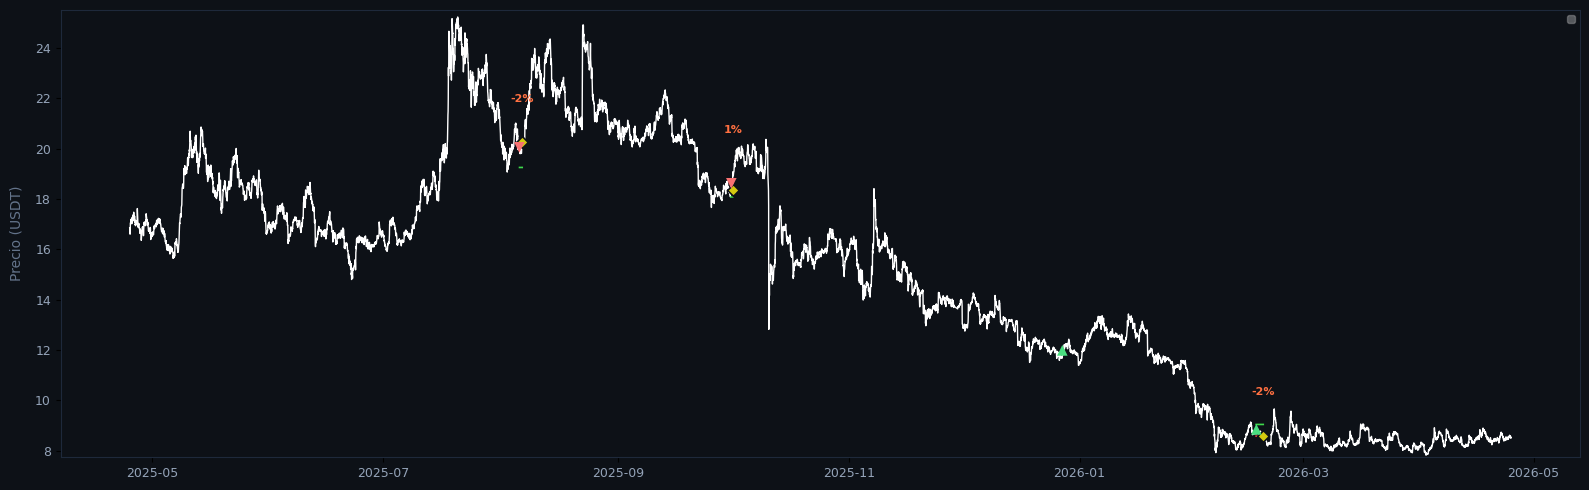

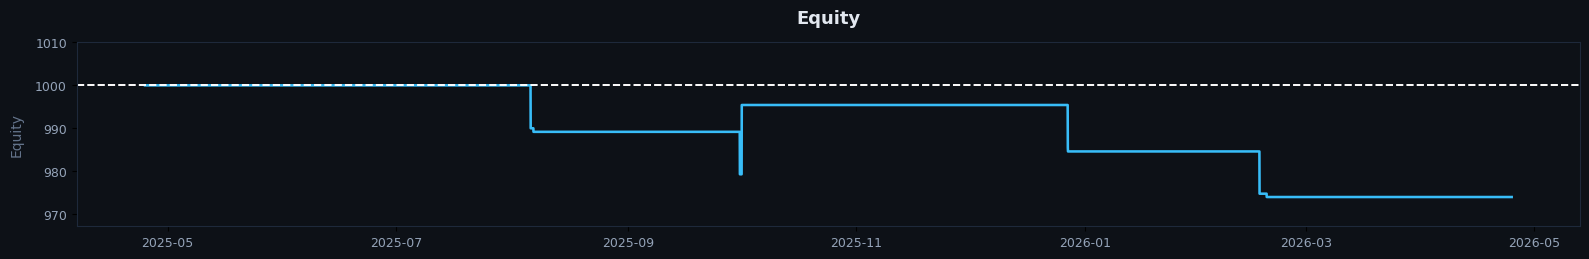

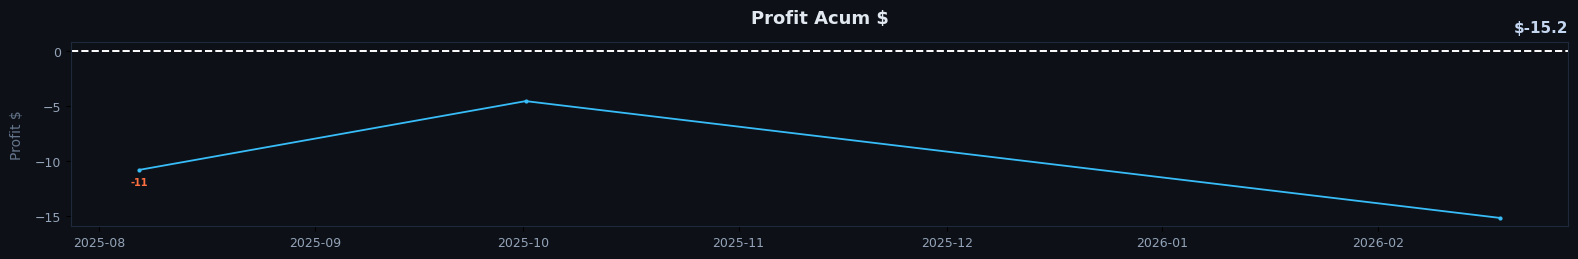

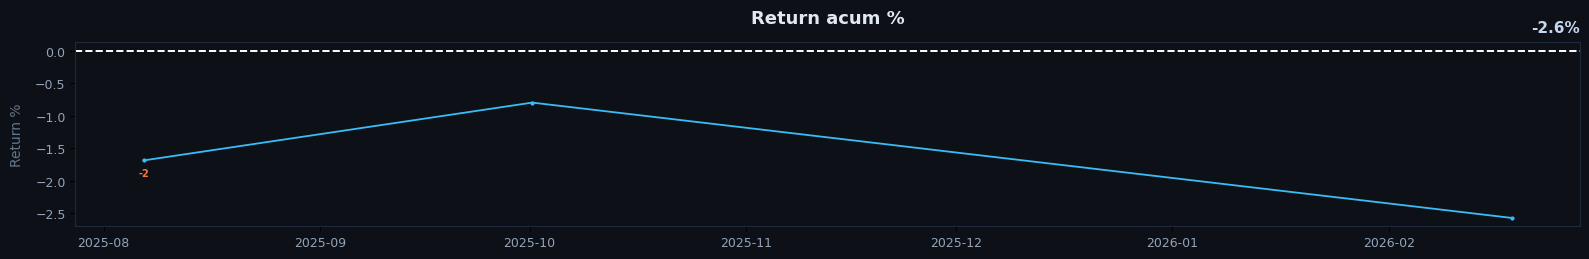

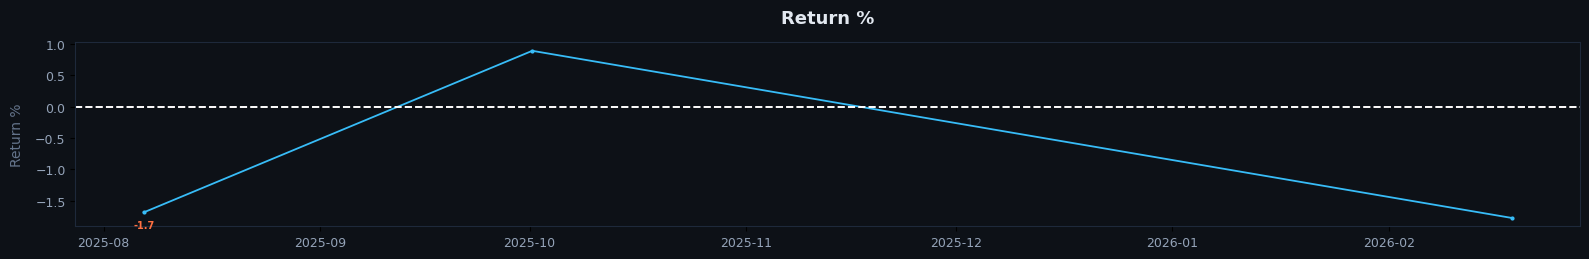

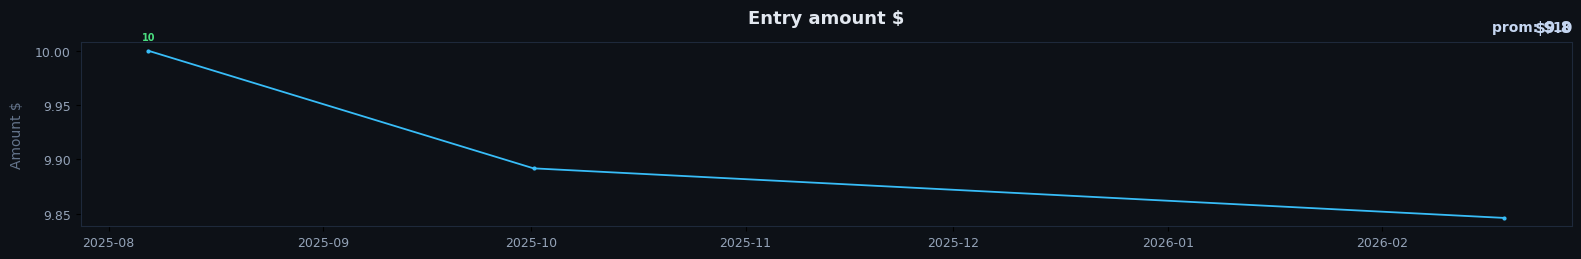

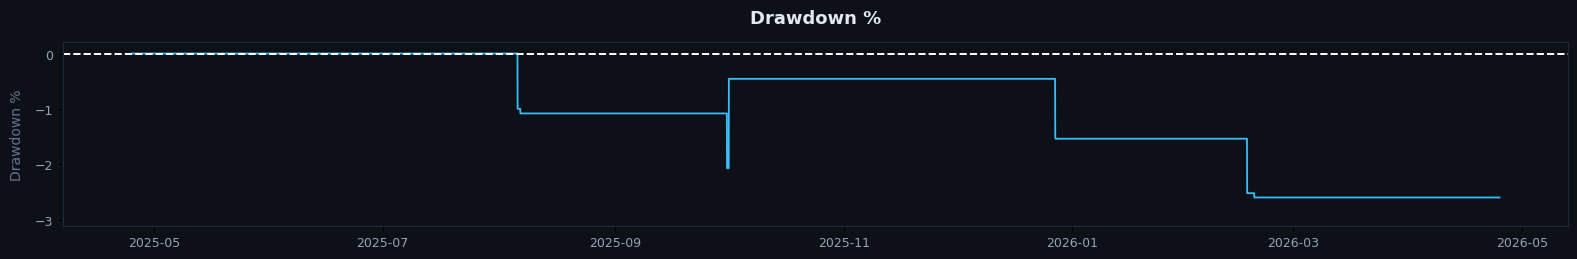

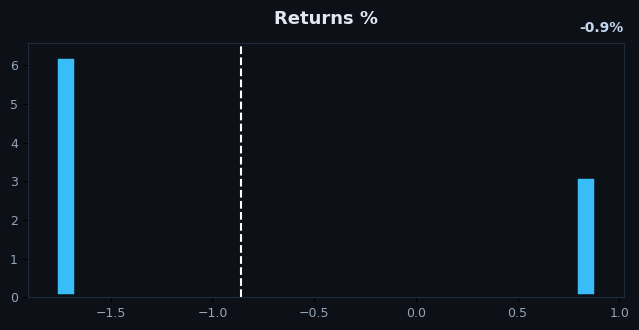

In [ ]:
# Price
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# state["std"] = state["close"].rolling(20).std()
# state["bb_low"] = state["close"] - 2*state["std"]
# state["bb_upper"] = state["close"] + 2*state["std"]

state["time"] = pd.to_datetime(state["time"])
state["Close"] = state["close"]
sell = state[state["signal"] == -1]
buy  = state[state["signal"] ==  1]
exits = state.copy()
exits = exits[exits["state"] == "EXIT"]

fig, ax = plt.subplots(figsize=(16, 5))
color_back = "#0d1117"
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(state["time"], state["Close"], color="#ffffff", linewidth=1, zorder=2)

# # EMAS
# # state["EMA"] = state["close"].rolling(window = 200).mean()
# ax.plot(state["time"], state["EMA"], color="#610871", linewidth=1, zorder=2, linestyle = "-", label = "EMA200")
# # state["EMA2"] = state["close"].rolling(window = 50).mean()
# ax.plot(state["time"], state["EMA2"], color="#6F4C0C", linewidth=1, zorder=2, linestyle = "-", label = "EMA50")
# # Bollinger
# ax.plot(state["time"], state["bb_low"], color="#143868", linewidth=1, zorder=2, linestyle = "--")
# ax.plot(state["time"], state["bb_upper"], color="#143868", linewidth=1, zorder=2, linestyle = "--")
# SL
if "sl" in state.columns:
    sl_data = state
    ax.plot(sl_data["time"], sl_data["sl"], color="#ef4444", linewidth=1.2, alpha = 0.9, linestyle="-", zorder=3)#, marker = "o", markersize = 1)
# TP
if "tp" in state.columns:
    tp_data = state
    ax.plot(tp_data["time"], tp_data["tp"], color="#44ef52", linewidth=1.2, alpha = 0.9, linestyle="-", zorder=3)
# Sell signals
if not sell.empty:
    # ax.scatter(sell["time"], sell["Close"], color="#f87171", s=45, zorder=5, edgecolors="white", linewidths=1.1)
    for _, row in sell.iterrows():
        ax.annotate("▼", xy=(row["time"], row["Close"]), xytext=(0, 0),  zorder=6,textcoords="offset points", ha="center", fontsize=10, color="#f87171", fontweight="bold")
# Buy signals
if not buy.empty:
    # ax.scatter(buy["time"], buy["Close"], color="#4ade80", s=45, zorder=5, edgecolors="white", linewidths=1.1)
    for _, row in buy.iterrows():
        ax.annotate("▲", xy=(row["time"], row["Close"]), xytext=(0, 0),  zorder=6,textcoords="offset points", ha="center", fontsize=10, color="#4ade80", fontweight="bold")

if not exits.empty:
    for _, row in exits.iterrows():
        if row["reason"]  == "SL":
            t = "✖"
            color = "#ff7041"
            ypos = -22
        elif row["reason"] == "TP":
            t = "✔"
            color = "#4ade80"
            ypos = -22
        else: # TS
            t = "*"
            color = "#D3C90F"
            ypos = -22
        # ax.annotate(t, xy=(row["time"], row["Close"]*0.995), xytext=(0, 30), textcoords="offset points", ha="center", fontsize=11, color=color, fontweight="bold")
        ax.annotate(f"{row["return%"]*100:.0f}%", xy=(row["time"], row["Close"]*0.995), xytext=(0, 30), textcoords="offset points", ha="center", fontsize=8, 
                    color=color, fontweight="bold")
    ax.scatter(exits["time"], exits["close_exit"], color="#D3C90F", s=35, zorder=5, marker = "D", edgecolors=color_back, linewidths=1.2, label="")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid(False)
ax.set_title("", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Precio (USDT)", color="#64748b", fontsize=10, labelpad=8)
_min = min(state["sl"].min(), state["tp"].min(), state["Close"].min())*0.989
_max = max(state["sl"].max(), state["tp"].max(), state["Close"].max())*1.011
ax.set_ylim(_min, _max)
plt.legend(loc = "upper right", fontsize = 7, framealpha = 0.3, labelcolor = "white", frameon = True, handlelength=3.5, handleheight=1)
plt.tight_layout()
plt.show()



# Equity
state["Close"] = state["patrimony"]
sell = state[state["signal"] == -1]
buy  = state[state["signal"] ==  1]
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(state["time"], state["Close"], color="#38bdf8", linewidth=1.85, zorder=2, label="Close Price")
ax.axhline(capital, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Equity", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Equity", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylim(state["Close"].min()*0.993, state["Close"].max()*1.01)
plt.tight_layout()
plt.show()



# Profit Acum
profitcum = exits[["time", "profit", "return%", "reason"]]
profitcum["profitcum"] = profitcum["profit"].cumsum()
# profitcum["returncum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.3, marker = "o", markersize = 2, zorder=2)

nfactor = 5
lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    if row["profitcum"] > 0: # row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    else:
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.annotate(f"${profitcum["profitcum"].iloc[-1]:.1f}", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
             weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Profit Acum $", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Profit $", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()




# Returns acum
profitcum = exits[["time", "profit", "return%", "reason"]]
profitcum["return%"] = profitcum["return%"]*100
profitcum["profitcum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.3, marker = "o", markersize = 2, zorder=2)

lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    if row["profitcum"] > 0: # row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    else:
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.annotate(f"{profitcum["profitcum"].iloc[-1]:.1f}%", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
             weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Return acum %", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Return %", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()


# Returns
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
exits = state[state["state"] == "EXIT"]
exits["return%"] = exits["return%"]*100
ax.plot(exits["time"], exits["return%"], color="#38bdf8", linewidth=1.3, marker = "o", markersize = 2, zorder=2)

lista = [x for x in range(len(exits)) if x % nfactor == 0]

for _, row in exits.iloc[lista].iterrows():
    if row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    if row["reason"]  == "SL":
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["return%"]:.1f}", xy=(row["time"], row["return%"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Return %", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Return %", color="#64748b", fontsize=10, labelpad=8)
_min = exits["return%"].min()*1.8
_max = exits["return%"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()



# Entry amount
exits = state.copy()
exits["entry_amount"] = exits["entry_amount"].shift(1)
profitcum = exits[exits["state"] == "EXIT"]
profitcum["profitcum"] = profitcum["entry_amount"]
# profitcum["returncum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.3, marker = "o", markersize = 2, zorder=2)

lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7, color="#4ade80", fontweight="bold")
# ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.annotate(f"${profitcum["profitcum"].iloc[-1]:.1f}", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
             weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
prom = profitcum["profitcum"].mean()
plt.annotate(f"prom: ${prom:.0f}", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 10, weight = "bold", 
             color = "#c5d6f1")


plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Entry amount $", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Amount $", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()




# Drawdown
fig, ax = plt.subplots(figsize=(16, 2.7))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
drawd = state.copy()
drawd["drawdown"] = drawd["drawdown"]*100
ax.plot(drawd["time"], drawd["drawdown"], color="#38bdf8", linewidth=1.3, zorder=2, label="Close Price")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Drawdown %", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Drawdown %", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylim(drawd["drawdown"].min()*1.2, max(drawd["drawdown"].max()*1.1, 0.2))
plt.tight_layout()
plt.show()


# Hist returns
fig, ax = plt.subplots(figsize=(6.5, 3.4))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
exits = state[state["state"] == "EXIT"]
returns = (exits["return%"]*100)
plt.hist(returns, color="#38bdf8", density=True, bins = 25, edgecolor = color_back, linewidth = 4)
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
plt.axvline(np.mean(returns), linestyle = "--", color = "white")
plt.annotate(f"{np.mean(returns):.1f}%", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 10, weight = "bold", 
             color = "#c5d6f1")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
plt.title("Returns %", color = "#e2e8f0", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [ ]:
qwe

NameError: name 'qwe' is not defined

In [ ]:
# Optimizacion de parametros
"""
Parámetros que definitivamente debes probar
Gestión de la señal
FORWARD_WINDOW = 6 — las velas hacia adelante para validar si la señal fue correcta. Si lo bajas a 2-3 eres más estricto; si lo subes a 12-24 eres más permisivo. Esto no afecta el PnL real, solo la métrica signal_correct.
Gestión del riesgo (estos sí afectan el PnL)
ATR_SL = 1.5 — distancia del Stop Loss. Con valores bajos (0.5-1.0) el SL es muy ajustado y te saca con más frecuencia, incluso en movimientos normales. Con valores altos (2.0-3.0) aguanta más ruido pero la pérdida por trade es mayor.
ATR_TP = 3.0 — distancia del Take Profit. Lo más importante aquí es la relación con ATR_SL. Si ATR_TP / ATR_SL = 2.0 significa que ganas el doble de lo que arriesgas. Valores comunes a probar: 1:1, 1:1.5, 1:2, 1:3.
RISK_PCT = 0.01 — el 1% de riesgo por trade es el estándar institucional. Puedes probar 0.5% (muy conservador) o 2% (agresivo). Subir esto aumenta retornos pero también drawdowns proporcionalmente.
ATR period — el período del ATR (actualmente hardcodeado en 14) define qué tan sensible es la volatilidad. Con 7 reacciona más rápido a cambios de volatilidad; con 21 es más suave.
"""

In [ ]:
"""
* Rentabilidad general
Capital inicial $1,000
El dinero con el que empezó la simulación. Base de comparación para todo lo demás.
Neutral

Capital final $1,119
Lo que quedó al terminar el período. Incluye todas las ganancias, pérdidas y comisiones.
Bueno

Retorno estrategia +11.95%
Ganaste $119 sobre $1,000 iniciales. Lo más importante: superaste ampliamente al Buy & Hold en el mismo período.
Bueno

Retorno Buy & Hold -29.43%
Si hubieras comprado y sostenido sin operar, habrías perdido el 29%. Tu estrategia le ganó al mercado por +41 puntos porcentuales. Esto es alpha real.
+41pp alfa


* Actividad de trading
Total trades 361
Operaciones ejecutadas en 60 días ≈ 6 trades por día. Es alto; puede indicar overtrading o que la estrategia es muy activa. Más trades = más comisiones acumuladas.
Alto

Ganadoras 41.3%
Solo 4 de cada 10 trades terminan en ganancia. Parece bajo, pero es viable si las ganancias son mucho mayores que las pérdidas (ver Ratio R/R).
Bajo

Racha perdedora máx 11
Hubo un momento con 11 trades consecutivos perdedores. Con 1% de riesgo por trade esto representa ~10% de pérdida acumulada. Psicológicamente muy difícil de sostener en vivo.
Vigilar

Racha ganadora máx 5
Lo mejor fue 5 trades ganadores seguidos. La asimetría (11 pérdidas vs 5 ganancias seguidas) es normal cuando el winrate es bajo.
Normal


* Calidad del sistema
Profit Factor 1.06
Por cada $1 perdido, ganas $1.06. Significa que el sistema es rentable pero muy al límite. Por encima de 1.5 se considera robusto; 1.06 es frágil ante cambios de 
mercado o aumento de comisiones.
Frágil

Ratio R/R promedio 1.59
En promedio, cuando ganas obtienes 1.59x lo que pierdes cuando pierdes. Esto explica por qué el sistema sobrevive con solo 41% de aciertos: las ganancias compensan las pérdidas.
Bueno

Max Drawdown -15.05%
La caída máxima desde un pico hasta un valle fue del 15%. Sobre $1,000 son $150 de pérdida temporal. Es aceptable; por debajo de -20% empieza a ser preocupante.
Aceptable


* Métricas de riesgo ajustado
Sharpe Ratio 1.00
Mide retorno por unidad de riesgo total. Igual a 1.0 significa que el retorno compensa exactamente la volatilidad. <1 = malo, 1-2 = aceptable, >2 = bueno, >3 = excelente.
Aceptable

Sortino Ratio 1.67
Como el Sharpe pero solo penaliza la volatilidad bajista (las caídas). Que sea mayor que el Sharpe (1.67 vs 1.00) significa que la volatilidad de la estrategia viene más 
de subidas que de bajadas. Buena señal.
Bueno

Calmar Ratio 0.79
Retorno anualizado dividido entre el drawdown máximo. 0.79 significa que el retorno no llega a compensar el peor momento de caída. Por encima de 1.0 es lo deseable.
Mejorable


* Riesgo por trade 1%
En cada entrada se arriesga el 1% del capital disponible. Con 361 trades y rachas perdedoras de 11, esto es lo que evitó una pérdida catastrófica.
Conservador

SL × 1.5 ATR: 1.5x
El Stop Loss se coloca a 1.5 veces el ATR del precio de entrada. Suficientemente lejos para no ser alcanzado por ruido normal, pero con la racha de 11 perdedores 
seguidos podría estar muy ajustado.
Normal

TP × 3.0 ATR: 3.0x
Take Profit a 3x ATR = ratio riesgo/beneficio teórico de 1:2. Combinado con el 41% de aciertos, la matemática cierra: 0.41×2 - 0.59×1 = 0.23 de esperanza matemática positiva por trade.
Bueno
"""

In [ ]:
tengo el siguiente df con los datos del precio de una criptomoneda, en donde cada registro (vela) esta a una vetana de 1 hora, y tengo 60 dias de informacion. 
Tengo tambien una variable llamada "signal" que sale de una estrateiga que me indica cuando comprar, vender o esperar. Necesito hacer un backtesting para conocer el 
rendimineto de esta estrategia:
quiero que para que se considere correcta la operacion, el precio siga la tendencia dada por la señal en al menos 6 velas hacia adelante (por lo que el precio puede bajar o
subir velas antes, pero no afectarian el exito de la señal). Tambien quiero que se tenga en cuenta el cierre de la operacion usando el atr, por ejemplo 1.5 para colocar stop loss y take

## ML

In [ ]:
qwe

## Pairs 

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# =========================
# 1. DESCARGA DE DATOS
# =========================

def load_data(tickers, start="2020-01-01", end="2024-01-01"):
    data = yf.download(tickers, start=start, end=end)["Close"]
    data = data.dropna()
    return data


# =========================
# 2. COINTEGRACIÓN
# =========================

def find_best_pair(data):
    min_pvalue = 1
    best_pair = None

    for i in range(len(data.columns)):
        for j in range(i+1, len(data.columns)):
            s1 = data.iloc[:, i]
            s2 = data.iloc[:, j]

            _, pvalue, _ = coint(s1, s2)

            if pvalue < min_pvalue:
                min_pvalue = pvalue
                best_pair = (data.columns[i], data.columns[j])

    return best_pair


# =========================
# 3. SPREAD + ZSCORE
# =========================

def compute_spread(data, pair):
    s1 = data[pair[0]]
    s2 = data[pair[1]]

    beta = np.polyfit(s2, s1, 1)[0]

    spread = s1 - beta * s2
    zscore = (spread - spread.rolling(20).mean()) / spread.rolling(20).std()

    df = pd.DataFrame({
        "spread": spread,
        "zscore": zscore,
        "s1": s1,
        "s2": s2
    })

    return df


# =========================
# 4. SEÑALES
# =========================

def generate_signals(df):
    df = df.copy()
    df["position"] = 0

    # LONG spread
    df.loc[df["zscore"] < -2, "position"] = 1

    # SHORT spread
    df.loc[df["zscore"] > 2, "position"] = -1

    # cerrar
    df.loc[df["zscore"].abs() < 0.5, "position"] = 0

    df["position"] = df["position"].ffill()

    return df


# =========================
# 5. BACKTEST
# =========================

def backtest(df):
    df = df.copy()

    df["returns_s1"] = df["s1"].pct_change()
    df["returns_s2"] = df["s2"].pct_change()

    # estrategia market neutral
    df["strategy"] = df["position"].shift(1) * (
        df["returns_s1"] - df["returns_s2"]
    )

    df["equity"] = (1 + df["strategy"]).cumprod()

    return df


# =========================
# 6. MÉTRICAS
# =========================

def metrics(df):
    returns = df["strategy"].dropna()

    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    drawdown = (df["equity"] / df["equity"].cummax() - 1).min()
    total_return = df["equity"].iloc[-1] - 1

    return sharpe, drawdown, total_return


# =========================
# 7. PIPELINE COMPLETO
# =========================

def run(tickers):
    data = load_data(tickers)

    pair = find_best_pair(data)
    print("Mejor par:", pair)

    df = compute_spread(data, pair)
    df = generate_signals(df)
    df = backtest(df)

    sharpe, dd, ret = metrics(df)

    print(f"Sharpe: {sharpe:.2f}")
    print(f"Max Drawdown: {dd:.2%}")
    print(f"Return: {ret:.2%}")

    df["equity"].plot(title="Equity Curve")
    plt.show()

    return df


# =========================
# EJEMPLO
# =========================

tickers = ["AAPL", "MSFT", "GOOG", "AMZN"]

df_result = run(tickers)

## Correlaciones de indicadores

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. MAPEO DE SEÑALES ===================== #

signal_map = {
    "🟢": 1,
    "🔴": -1,
    "": 0,
    "⚪":0,
    "✅": 1,
    "🔥": 1,
    "✅": 0
}

def map_signal(series):
    return series.map(signal_map).fillna(0)


# ===================== 2. CREAR FEATURES ===================== #

def build_feature_matrix(results):

    features = pd.DataFrame()

    # Señales categóricas → numéricas
    global cols_signals

    for col in cols_signals:
        if col in results.columns:
            features[col] = map_signal(results[col])

    # Variables numéricas directas
    cols_numeric = [
        "RSI","EMA20","EMA50","EMA200",
        "price","bb_pos","atr"
    ]

    for col in cols_numeric:
        if col in results.columns:
            features[col] = pd.to_numeric(results[col], errors="coerce")

    # Opcionales si existen
    optional_cols = [
        "roc","stoch_rsi","vwap_dev"
    ]

    for col in optional_cols:
        if col in results.columns:
            features[col] = pd.to_numeric(results[col], errors="coerce")

    return features


# ===================== 3. CORRELACIÓN ===================== #

def compute_correlation(features):
    corr = features.corr(method="spearman")
    return corr


# ===================== 4. DETECTAR REDUNDANCIA ===================== #

def find_redundant_features(corr, threshold=0.7):

    redundant_pairs = []

    for i in range(len(corr.columns)):
        for j in range(i):
            val = corr.iloc[i, j]
            if abs(val) >= threshold:
                col1 = corr.columns[i]
                col2 = corr.columns[j]
                redundant_pairs.append((col1, col2, round(val, 3)))

    return pd.DataFrame(redundant_pairs, columns=["feature_1", "feature_2", "correlation"])


# ===================== 5. VISUALIZACIÓN ===================== #

def plot_correlation(corr):
    plt.figure(figsize=(12,10))
    plt.imshow(corr, cmap="coolwarm", aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix (Spearman)")
    plt.tight_layout()
    plt.show()


# ===================== 6. CLUSTERING ===================== #

def plot_clustering(features):
    from scipy.cluster.hierarchy import linkage, dendrogram

    corr = features.corr().fillna(0)
    linked = linkage(corr, method='ward')

    plt.figure(figsize=(10,7))
    dendrogram(linked, labels=corr.columns)
    plt.title("Clustering de Indicadores")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


# ===================== 7. IMPORTANCIA (ML OPCIONAL) ===================== #

def feature_importance(results, features, target_col):

    from sklearn.ensemble import RandomForestClassifier

    df = features.copy()
    df[target_col] = results[target_col]

    df = df.dropna()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False)

    return importance


# ===================== 8. PIPELINE COMPLETO ===================== #

def analyze_indicators(results, target_col=None, corr_threshold=0.8):

    print("\n🔧 Construyendo matriz de features...")
    features = build_feature_matrix(results)

    print("📊 Calculando correlación...")
    corr = compute_correlation(features)

    print("🔍 Detectando redundancias...")
    redundant = find_redundant_features(corr, threshold=corr_threshold)

    print("\n📌 PARES REDUNDANTES:")
    print(redundant.sort_values("correlation", ascending=False))

    print("\n✅ Mostrando matriz de correlación...")
    plot_correlation(corr)

    print("\n🌳 Clustering de indicadores...")
    plot_clustering(features)

    if target_col and target_col in results.columns:
        print("\n🧠 Calculando importancia de features...")
        importance = feature_importance(results, features, target_col)

        print("\n🏆 IMPORTANCIA:")
        print(importance)

        return features, corr, redundant, importance

    return features, corr, redundant


# ===================== USO ===================== #

# Ejemplo:
features, corr, redundant = analyze_indicators(results)

In [ ]:
results

In [ ]:
features

In [ ]:
ax = corr.reset_index()
ax = pd.melt(ax, id_vars="index")
ax["value"] = abs(ax["value"])
ax = ax.sort_values("value", ascending = False)
ax = ax[ax["index"] != ax["variable"]].drop_duplicates("value")
ax.head(10)

## Portafolio y frontera eficiente

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. DESCARGA DE DATOS ===================== #

def load_data(symbols, period="1y", interval="1d"):
    data = yf.download(
        symbols,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )["Close"]

    # limpiar
    data = data.dropna(axis=1, how="all")
    data = data.fillna(method="ffill")

    return data


# ===================== 2. RETORNOS ===================== #

def compute_returns(df):
    returns = df.pct_change().dropna()
    return returns


# ===================== 3. CORRELACIÓN ENTRE ACTIVOS ===================== #

def compute_correlation(returns):
    corr = returns.corr(method="spearman")
    return corr


# ===================== 4. DETECTAR PARES MUY CORRELACIONADOS ===================== #

def find_high_corr_pairs(corr, threshold=0.8):
    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i):
            val = corr.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append((corr.columns[i], corr.columns[j], round(val, 3)))

    return pd.DataFrame(pairs, columns=["asset_1", "asset_2", "correlation"])


# ===================== 5. REDUCIR UNIVERSO (ELIMINAR REDUNDANTES) ===================== #

def filter_uncorrelated_assets(corr, threshold=0.8):
    selected = []
    assets = list(corr.columns)

    for asset in assets:
        keep = True
        for sel in selected:
            if abs(corr.loc[asset, sel]) >= threshold:
                keep = False
                break
        if keep:
            selected.append(asset)

    return selected


# ===================== 6. FRONTERA EFICIENTE ===================== #

def efficient_frontier(returns, n_portfolios=5000):

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    results = {
        "returns": [],
        "volatility": [],
        "sharpe": [],
        "weights": []
    }

    num_assets = len(returns.columns)

    for _ in range(n_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)

        port_return = np.dot(weights, mean_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

        sharpe = port_return / port_vol

        results["returns"].append(port_return)
        results["volatility"].append(port_vol)
        results["sharpe"].append(sharpe)
        results["weights"].append(weights)

    return pd.DataFrame(results), mean_returns, cov_matrix


# ===================== 7. PLOT FRONTERA ===================== #

def plot_frontier(df):
    plt.figure(figsize=(10,6))
    sc = plt.scatter(df["volatility"], df["returns"], c=df["sharpe"])
    plt.colorbar(sc, label="Sharpe Ratio")
    plt.xlabel("Volatility")
    plt.ylabel("Return")
    plt.title("Efficient Frontier")
    plt.show()


# ===================== 8. PIPELINE COMPLETO ===================== #

def portfolio_analysis(symbols):

    print("📥 Descargando datos...")
    prices = load_data(symbols)

    print("📊 Calculando retornos...")
    returns = compute_returns(prices)

    print("🔗 Calculando correlaciones...")
    corr = compute_correlation(returns)

    print("🔍 Buscando pares altamente correlacionados...")
    high_corr = find_high_corr_pairs(corr, threshold=0.8)

    print("\n📌 PARES CORRELACIONADOS:")
    print(high_corr.sort_values("correlation", ascending=False).head(20))

    print("\n🧹 Filtrando activos no redundantes...")
    selected_assets = filter_uncorrelated_assets(corr, threshold=0.8)

    print(f"\n✅ Activos seleccionados ({len(selected_assets)}):")
    print(selected_assets)

    print("\n✅ Calculando frontera eficiente...")
    filtered_returns = returns[selected_assets]

    frontier_df, mean_returns, cov_matrix = efficient_frontier(filtered_returns)

    plot_frontier(frontier_df)

    # mejor portafolio (Sharpe máximo)
    best_idx = frontier_df["sharpe"].idxmax()
    best_port = frontier_df.loc[best_idx]

    print("\n🏆 MEJOR PORTAFOLIO:")
    print("Return:", best_port["returns"])
    print("Volatility:", best_port["volatility"])
    print("Sharpe:", best_port["sharpe"])

    return {
        "prices": prices,
        "returns": returns,
        "correlation": corr,
        "high_corr_pairs": high_corr,
        "selected_assets": selected_assets,
        "frontier": frontier_df,
        "best_portfolio": best_port
    }


# ===================== USO ===================== #

# symbols = ["AAPL","MSFT","NVDA","TSLA","AMZN","META","GOOGL","NFLX", ...]
# result = portfolio_analysis(symbols)

## Pairs trading

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


# ===================== 1. DATA ===================== #

def load_prices(symbols, period="1y"):
    data = yf.download(symbols, period=period, auto_adjust=True, progress=False)["Close"]
    return data.dropna(axis=1, how="all").ffill()


# ===================== 2. FILTRO CORRELACIÓN ===================== #

def filter_by_correlation(data, threshold=0.7):
    returns = data.pct_change().dropna()
    corr = returns.corr()

    pairs = []
    cols = corr.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr.iloc[i, j]) > threshold:
                pairs.append((cols[i], cols[j]))

    return pairs


# ===================== 3. COINTEGRACIÓN ===================== #

def filter_cointegration(data, pairs, pvalue_threshold=0.05):

    selected = []

    for a1, a2 in pairs:
        try:
            _, pvalue, _ = coint(data[a1], data[a2])
            if pvalue < pvalue_threshold:
                selected.append((a1, a2, pvalue))
        except:
            continue

    return sorted(selected, key=lambda x: x[2])


# ===================== 4. HEDGE RATIO DINÁMICO ===================== #

def rolling_beta(y, x, window=60):

    betas = []

    for i in range(len(y)):
        if i < window:
            betas.append(np.nan)
            continue

        y_win = y.iloc[i-window:i]
        x_win = x.iloc[i-window:i]

        model = sm.OLS(y_win, sm.add_constant(x_win)).fit()
        betas.append(model.params[1])

    return pd.Series(betas, index=y.index)


# ===================== 5. SPREAD + ZSCORE ===================== #

def compute_spread(data, a1, a2):

    s1 = data[a1]
    s2 = data[a2]

    beta = rolling_beta(s1, s2)

    spread = s1 - beta * s2

    # Z-score rolling
    mean = spread.rolling(60).mean()
    std = spread.rolling(60).std()

    zscore = (spread - mean) / std

    return spread, zscore, beta


# ===================== 6. BACKTEST ===================== #

def backtest(data, a1, a2, zscore):

    r1 = data[a1].pct_change().fillna(0)
    r2 = data[a2].pct_change().fillna(0)

    position = 0
    equity = []

    entry = 2
    exit = 0.5
    stop = 3

    for i in range(len(zscore)):

        z = zscore.iloc[i]

        if np.isnan(z):
            equity.append(0)
            continue

        # entradas
        if z < -entry:
            position = 1   # long spread
        elif z > entry:
            position = -1  # short spread

        # salida normal
        elif abs(z) < exit:
            position = 0

        # stop loss
        elif abs(z) > stop:
            position = 0

        ret = position * (r1.iloc[i] - r2.iloc[i])
        equity.append(ret)

    equity = pd.Series(equity, index=data.index)

    return equity.cumsum()


# ===================== 7. PIPELINE ===================== #

def run_pairs_trading(symbols):

    print("📥 Cargando datos...")
    prices = load_prices(symbols)

    print("🔗 Filtrando por correlación...")
    corr_pairs = filter_by_correlation(prices)

    print(f"Pares correlacionados: {len(corr_pairs)}")

    print("🧠 Filtrando cointegración...")
    pairs = filter_cointegration(prices, corr_pairs)

    if len(pairs) == 0:
        print("❌ No hay pares válidos")
        return

    a1, a2, pval = pairs[0]

    print(f"\n🎯 Par seleccionado: {a1} - {a2} (p={pval:.4f})")

    spread, zscore, beta = compute_spread(prices, a1, a2)

    equity = backtest(prices, a1, a2, zscore)

    # plots
    plt.figure(figsize=(12,4))
    plt.plot(spread)
    plt.title("Spread")
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(zscore)
    plt.axhline(2)
    plt.axhline(-2)
    plt.axhline(0)
    plt.title("Z-score")
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(equity)
    plt.title("Equity Curve")
    plt.show()

    return equity


# ===================== USO ===================== #

# symbols = ["AAPL","MSFT","NVDA","TSLA","AMZN","META","GOOGL","NFLX"]
# run_pairs_trading(symbols)

### Model ML

## Conexion con MT5

In [ ]:
results = pd.DataFrame({
    "symbol": ["ZECUSD"],
    "signal": ["SELL"],
    "sl":[346],
    "tp":[300],
    "lot":[0.1],
    "ATR":[3.5]
})

In [ ]:
import MetaTrader5 as mt5
if not mt5.initialize():
    print("Error al conectar:", mt5.last_error())
    quit()
print("Conectado a MT5 🚀")


def get_asset_type(symbol):
    s = symbol.upper()

    if len(s) == 6 and s.endswith("-USD"):
        return "forex"
    elif s in symbs_crypto:
        return "crypto"
    else:
        return "stock"


def get_config(symbol):

    asset = get_asset_type(symbol)

    if asset == "forex":
        return {
            "sl_mult": 1.2,
            "tp_mult": 2.5,
            "deviation": 10
        }

    elif asset == "crypto":
        return {
            "sl_mult": 2.0,
            "tp_mult": 4.0,
            "deviation": 50
        }

    else:  # stocks
        return {
            "sl_mult": 1.5,
            "tp_mult": 3.0,
            "deviation": 20
        }
    
def hay_posicion(symbol):
    posiciones = mt5.positions_get(symbol=symbol)
    return posiciones is not None and len(posiciones) > 0

def ejecutar_trade(row):
    symbol = row["symbol"]
    signal = row["signal"]
    atr = row["ATR"]
    mt5.symbol_select(symbol, True)

    tick = mt5.symbol_info_tick(symbol)
    info = mt5.symbol_info(symbol)

    if tick is None or info is None:
        print(f"Error con {symbol}")
        return

    if hay_posicion(symbol):
        print(f"{symbol}: Now active order")
        return

    config = get_config(symbol)

    if pd.isna(atr):
        print(f"ATR no disponible para {symbol}")
        return

    if signal == "BUY":
        price = tick.ask
        sl = price - atr * config["sl_mult"]
        tp = price + atr * config["tp_mult"]
        order_type = mt5.ORDER_TYPE_BUY

    elif signal == "SELL":
        price = tick.bid
        sl = price + atr * config["sl_mult"]
        tp = price - atr * config["tp_mult"]
        order_type = mt5.ORDER_TYPE_SELL

    else:
        return

    point = info.point
    digits = info.digits
    stop_level = info.trade_stops_level

    min_distance = stop_level * point

    # Ajustar SL/TP si están muy cerca
    if abs(price - sl) < min_distance:
        sl = price - min_distance if signal == "BUY" else price + min_distance

    if abs(price - tp) < min_distance:
        tp = price + min_distance if signal == "BUY" else price - min_distance

    # Redondeo correcto
    price = round(price, digits)
    sl = round(sl, digits)
    tp = round(tp, digits)

    request = {
        "action"      :  mt5.TRADE_ACTION_DEAL,
        "symbol"      : symbol,
        "volume"      : row["lot"],
        "type"        : order_type,
        "price"       : price,
        "deviation"   : config["deviation"],
        # "sl"          : sl,
        # "tp"          : tp,
        "magic"       : 123456,
        "comment"     : "bot_python",
        "type_time"   : mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }

    result = mt5.order_send(request)
    print(f"{symbol} -> {signal}:", result[7], f"| lot: {request["volume"]}")
    print(f"ATR: {atr}")
    print(f"SL: {sl} | TP: {tp}")
    print(result)

In [ ]:
for _, row in results.iterrows():
    ejecutar_trade(row)

In [ ]:
symbol = "ZECUSD"
mt5.symbol_select(symbol, True)

tick = mt5.symbol_info_tick(symbol)
info = mt5.symbol_info(symbol)

point = info.point
digits = info.digits
stop_level = info.trade_stops_level  # 🔥 clave

print("Stops level:", info.trade_stops_level)
print("Point:", info.point)

In [ ]:
# Automatize
# import time
# while True:
#     for _, row in df.iterrows():
#         ejecutar_trade(row["symbol"], row["signal"])
    
#     time.sleep(10*60)  # minuto

In [ ]:
# Consumir historial de trades
date = "2026-04-15"
import MetaTrader5 as mt5
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

# =========================================================
# 1. CONEXIÓN
# =========================================================
if not mt5.initialize():
    raise RuntimeError(f"Error al conectar con MT5: {mt5.last_error()}")

# =========================================================
# 2. DESCARGAR HISTORIAL
# =========================================================
date_from = datetime(2024, 1, 1)
date_to = datetime.now()

deals = mt5.history_deals_get(date_from, date_to)

if deals is None or len(deals) == 0:
    mt5.shutdown()
    raise ValueError("No hay datos de trades en ese rango de fechas")

# =========================================================
# 3. CONVERTIR A DATAFRAME
# =========================================================
df = pd.DataFrame(list(deals), columns=deals[0]._asdict().keys())

# tiempo
df["time"] = pd.to_datetime(df["time"], unit="s")

# solo BUY / SELL
df = df[df["type"].isin([0, 1])]

# mapear tipo
df["type"] = df["type"].map({0: "buy", 1: "sell"})

# =========================================================
# 4. RECONSTRUIR TRADES (ENTRY + EXIT)
# =========================================================
trades = []

for position_id, group in df.groupby("position_id"):

    group = group.sort_values("time")

    if len(group) < 2:
        continue

    entry = group.iloc[0]
    exit_ = group.iloc[-1]

    trades.append({
        "position_id": position_id,
        "symbol": entry["symbol"],
        "type": entry["type"],
        "entry_time": entry["time"],
        "exit_time": exit_["time"],
        "entry_price": entry["price"],
        "exit_price": exit_["price"],
        "volume": entry["volume"],
        "profit": group["profit"].sum(),
        "swap": group["swap"].sum(),
        "comment": group["comment"].sum(), # Probar si es entry
        "commission": group["commission"].sum()
    })

trades_df = pd.DataFrame(trades)

# =========================================================
# 5. CALCULAR RETURNS
# =========================================================
trades_df["return"] = (
    (trades_df["exit_price"] - trades_df["entry_price"]) / trades_df["entry_price"]
)

trades_df.loc[trades_df["type"] == "sell", "return"] *= -1

trades_df["result"] = np.where(trades_df["profit"] > 0, "win", "loss")
trades_df["entry_time"] = pd.to_datetime(trades_df["entry_time"])
trades_df = trades_df[trades_df["entry_time"] >= date]

# =========================================================
# 6. MÉTRICAS
# =========================================================
winrate = (trades_df["result"] == "win").mean()
avg_return = trades_df["return"].mean()
total_profit = trades_df["profit"].sum()

wins = trades_df[trades_df["return"] > 0]["return"]
losses = trades_df[trades_df["return"] <= 0]["return"]

profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 else np.nan

expectancy = (
    winrate * wins.mean() + (1 - winrate) * losses.mean()
    if len(wins) > 0 and len(losses) > 0 else np.nan
)

print("\n========== MÉTRICAS ==========")
print("Trades:", len(trades_df))
print("Winrate:", round(winrate, 3))
print("Avg Return:", round(avg_return, 5))
print("Profit Factor:", round(profit_factor, 3))
print("Expectancy:", round(expectancy, 5))
print("Total Profit:", round(total_profit, 2))

# =========================================================
# 7. EQUITY CURVE
# =========================================================
trades_df = trades_df.sort_values("exit_time")

trades_df["equity"] = trades_df["profit"].cumsum()

plt.figure(figsize=(12,5))
plt.plot(trades_df["exit_time"], trades_df["equity"])
plt.title("Equity Curve (MT5 Real Trades)")
plt.grid()
plt.show()

# =========================================================
# 8. DRAWDOWN Y CALMAR
# =========================================================
equity = trades_df["equity"]

peak = equity.cummax()
drawdown = equity - peak
drawdown_pct = drawdown / peak

max_dd = drawdown_pct.min()

total_return = equity.iloc[-1] / abs(equity.iloc[0] if equity.iloc[0] != 0 else 1)
calmar = total_return / abs(max_dd) if max_dd != 0 else np.nan

print("\n========== RIESGO ==========")
print("Max Drawdown:", round(max_dd, 3))
print("Calmar:", round(calmar, 3))

# =========================================================
# 9. EXPORTAR (OPCIONAL)
# =========================================================
# trades_df.to_csv("mt5_trades.csv", index=False)

# cerrar conexión
mt5.shutdown()

In [ ]:
trades_df

In [ ]:
trades_df["comment"].value_counts()

In [ ]:
group

In [ ]:
entry

In [ ]:
# ayudame haciendo un algoritmo en python que me indique cuando colocar una pocision de venta y compra de FOREX, con estos simbolos: "BTC-USD", "ETH-USD", "XRP-USD", "LTC-USD", "ADA-USD", . Necesito que uses yahoo finance y operar a una ventana de 4 horas por vela. Necesito que cada vez que corra el algoritmo me indique por cada simbolo si debo comprar, vender, o esperar, crea las reglas teniendo en cuenta los indicadores tecnicos que necesites. Busca la mejor estrategia posible. Necesito que definas automaticamente el take profit y stop loss. Ademas pon un parametro del minimo de reglas que se cumplan para decidir o no colocar la posicion